# <strong>Examining the Determinants of Childhood Depression Among Children in Malawi</strong>
### Machine Learning in Python (MATH112052025)


**Group Project**

## Setup And Helper Function

In [1]:
#%pip install pyreadstat
#%pip install catboost
#%pip install missingno
#%pip install imbalanced-learn
#%pip install shap

In [2]:
# Data libraries
import pandas as pd
import numpy as np
import scipy.sparse as sp

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    classification_report, accuracy_score, roc_auc_score,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
)
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import chi2_contingency, pointbiserialr, pearsonr, skew, yeojohnson
from sklearn.inspection import PartialDependenceDisplay
import shap

# CatBoost modules
import catboost
from catboost import CatBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# import sav
import pyreadstat

# surpress warning
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# check missingness
import missingno as msno

# import module from plotting
import plotting as plt2

<p style="text-align: justify;">
The <code>NumericCleaner</code> is a custom Scikit-Learn transformer that automates the stabilisation of numerical distributions by combining outlier mitigation with skewness correction. During the fitting process, it calculates robust boundaries using the Interquartile Range (IQR) or percentile methods to cap extreme values, followed by an automated assessment of feature skewness to determine the optimal mathematical correction. If a feature exceeds the skewness threshold, the class dynamically selects between a Log1p transformation for positive values or a Yeo-Johnson transformation for datasets including zero or negative numbers. By storing these specific clipping bounds and transformation parameters during training, the transformer ensures rigorous consistency across datasets and prevents data leakage, making it an essential component for linear models that are sensitive to non-normal distributions and extreme outliers.
</p>

In [3]:
class NumericCleaner(BaseEstimator, TransformerMixin):

    """
    A custom transformer for Scikit-Learn pipelines that automatically 
    caps outliers and transforms skewed numerical distributions.
    """
    
    def __init__(self, outlier_method='iqr', iqr_factor=1.5, skew_threshold=0.75):
        # Parameters for outlier detection ('iqr' or percentile-based)
        self.outlier_method = outlier_method
        self.iqr_factor = iqr_factor
        # The absolute skewness value above which a transformation is applied
        self.skew_threshold = skew_threshold
        # Dictionary to store fitted parameters (bounds, lambdas) for each column
        self.column_params_ = {}   # store lower/upper bounds and transformation lambdas

    def fit(self, X, y=None):
        """
        To calculate outlier boundaries and determines the best transformation 
        for each column based on training data.
        """
        X = pd.DataFrame(X)  # ensure DataFrame
        for col in X.columns:
            col_data = X[col].dropna()
            # calculate outlier bounds
            if self.outlier_method == 'iqr':
                # Interquartile Range (IQR) Method
                Q1 = col_data.quantile(0.25)
                Q3 = col_data.quantile(0.75)
                IQR = Q3 - Q1
                lower = Q1 - self.iqr_factor * IQR
                upper = Q3 + self.iqr_factor * IQR
            else:
                # Percentile Method (defaulting to 1st and 99th percentiles)
                lower, upper = col_data.quantile(0.01), col_data.quantile(0.99)
            
            # determining skewness and transformation
            # Compute skew after capping (on training data)
            capped = col_data.clip(lower, upper)
            skew_val = skew(capped)
            transform = None
            lambda_ = None

            # If skewness exceeds threshold, choose a transformation
            if abs(skew_val) > self.skew_threshold:
                if (capped > 0).all():
                    # Log transformation is suitable for strictly positive data
                    transform = 'log1p'
                else:
                    # Yeo-Johnson handles zero and negative values; 
                    # we fit and store the lambda parameter
                    transform = 'yeojohnson'
                    _, lambda_ = yeojohnson(capped)
            
            # Store the learned parameters for use in the transform method
            self.column_params_[col] = {
                'lower': lower, 'upper': upper,
                'transform': transform, 'lambda': lambda_
            }
        return self

    def transform(self, X):
        """
        To apply the boundaries and transformations learned in 'fit' 
        to the provided data.
        """
        X = pd.DataFrame(X).copy() # using a copy to avoid SettingWithCopyWarning
        for col in X.columns:
            # Retrieve the parameters learned for this specific column
            params = self.column_params_[col]
            # 1. Cap outliers
            X[col] = X[col].clip(params['lower'], params['upper'])
            # 2. Apply transformation if needed
            if params['transform'] == 'log1p':
                X[col] = np.log1p(X[col])
            elif params['transform'] == 'yeojohnson':
                # Apply Yeo-Johnson using the lambda found during fitting
                X[col] = yeojohnson(X[col], lmbda=params['lambda'])
        return X.values # Return as a NumPy array for Scikit-Learn compatibility
    
    def get_feature_names_out(self, input_features=None):
        """Pass through feature names unchanged."""
        return np.array(input_features)

<strong>Model Performance Function</strong>

<p style="text-align: justify;">
<code>tune_threshold()</code> is function to systematically tests thresholds between 0.10 and 0.91, recording precision, recall, and F1-score at each step. Among all thresholds where precision meets the minimum of 0.6, the one that produce the highest recall is selected. This step ensures the model remains sensitive enough to catch depressed children without flagging too many children who are not actually at risk. After settling on a threshold, the function prints accuracy, F1, ROC-AUC, and a classification report. Also, combine three plots in a single figure, showing how each metric shifts across the threshold range, precision-recall tradeoff curve, and confusion matrix at the chosen cutoff.
</p>

In [4]:
def tune_threshold(model,X_test,y_test,model_name="Model",min_prec=0.60,thresholds=np.arange(0.10, 0.91, 0.001)):
    
    '''
    Function to tune classification threshild by searching for highest recall among conditional treshold

    Input argument : 
    1. model = model training
    2. X_test = X test
    3. y_test = y test
    4. min_prec = minimum recall a threshold must achieve
    5. thresholds = thresholds to be checked
  
    Output : threshold_results table, best_threshold, y_pred_tuned vector
    '''
    
    # Predicted probability
    y_prob=model.predict_proba(X_test)[:,1]

    # evaluate precision, recall, F1,and confusion matrix counts across every threshold
    results = []
    for t in thresholds:
        y_pred_t=(y_prob>=t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test,y_pred_t).ravel()
        results.append({
            "threshold":t,
            "precision": precision_score(y_test, y_pred_t, zero_division=0),
            "recall": recall_score(y_test, y_pred_t, zero_division=0),
            "f1": f1_score(y_test, y_pred_t, zero_division=0),
            "false_negatives": fn,
            "false_positives": fp,
            "true_negatives": tn,
            "true_positives": tp
        })

    threshold_results= pd.DataFrame(results)

    # pick the highest recall with minimum precision of 0.60
    candidates=threshold_results[threshold_results["precision"]>= min_prec]
    best_row=candidates.loc[candidates["recall"].idxmax()]
    best_threshold=best_row["threshold"]

    print(f"Chosen threshold: {best_threshold}")
    display(best_row)

    # Final tuned prediction
    y_pred_tuned=(y_prob>=best_threshold).astype(int)

    # print evaluation matrix
    print(f"\n=== {model_name} with Tuned Threshold ===")
    print(f"Chosen threshold : {best_threshold:.3f}")
    print(f"Accuracy         : {accuracy_score(y_test, y_pred_tuned):.4f}")
    print(f"F1-score         : {f1_score(y_test, y_pred_tuned):.4f}")
    print(f"ROC-AUC          : {roc_auc_score(y_test, y_prob):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_tuned))

    # Make all plot into one grdi
    precision_curve,recall_curve,_= precision_recall_curve(y_test, y_prob)
    ap_score= average_precision_score(y_test, y_prob)

    fig,axes=plt.subplots(1, 3, figsize=(18, 5))

    # threshold tuning curve
    axes[0].plot(threshold_results["threshold"],threshold_results["precision"], label="Precision")
    axes[0].plot(threshold_results["threshold"],threshold_results["recall"], label="Recall")
    axes[0].plot(threshold_results["threshold"],threshold_results["f1"],label="F1-score")
    axes[0].axvline(best_threshold, linestyle="--", color="black",label=f"Chosen = {best_threshold:.3f}")
    axes[0].set_xlabel("Threshold")
    axes[0].set_ylabel("Score")
    axes[0].set_title("Threshold Tuning Curve")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Precision-Recall curve
    axes[1].plot(recall_curve, precision_curve, linewidth=2)
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"Precision-Recall Curve (AP = {ap_score:.3f})")
    axes[1].grid(alpha=0.3)

    # Confusion matrix at chosen threshold
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred_tuned,cmap="Blues",ax=axes[2])
    axes[2].set_title(f"Confusion Matrix (threshold = {best_threshold:.3f})")

    plt.suptitle(f"{model_name} — Evaluation", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    return threshold_results,best_threshold,y_pred_tuned

<strong>Plotting Final Model Result</strong> 

<p style="text-align: justify;">
Creating a <code>plot_model_explainability</code> function to provide a multidimensional evaluation of the model by integrating global parameter analysis, predictive utility, and local feature attribution. It utilises Linear Coefficients with a custom filtering logic to highlight the strongest categorical impacts, Permutation Importance to measure the actual drop in Recall when feature signals are disrupted, and SHAP Beeswarm plots to visualize how specific feature values drive individual predictions.
</p>

In [ ]:
def plot_coefficients(model, title_map=None, top_n=15, figsize=(10, 5), ax=None):
    """
    To extract and plot coefficients from a fitted linear model.
    For categorical features, only shows the single category with the highest impact per feature.
    Red bars indicate positive influence, Blue indicate negative.
    """
    # Extracting the actual estimator from the Scikit-Learn pipeline
    final_estimator = model.named_steps['model']
    
    # Check if the model is linear (has .coef_ attribute)
    if not hasattr(final_estimator, 'coef_'):
        print("Model does not have coefficients — skipping.")
        return None

    # Get feature names from the preprocessor step
    feature_names_preproc = model.named_steps['preprocessor'].get_feature_names_out()
    coef = final_estimator.coef_[0]

    # creating initial DataFrame
    coef_df = pd.DataFrame({
        'RawName': feature_names_preproc,
        'Coefficient': coef
    })

    # identifying the base feature
    def get_base_feature(name):
        if name.startswith('cat__'):
            # Split by underscores and take everything before the last underscore (the category)
            return "_".join(name.split('_')[:-1])
        return name

    coef_df['BaseFeature'] = coef_df['RawName'].apply(get_base_feature)
    coef_df['AbsCoef'] = coef_df['Coefficient'].abs()

    # for each base feature, keep only the row with the max absolute coefficient
    coef_df = coef_df.sort_values('AbsCoef', ascending=False).drop_duplicates('BaseFeature')

    # Apply mapping/cleaning for display
    if title_map is not None:
        coef_df['Feature'] = [_clean_shap_name(f, title_map) for f in coef_df['RawName']]
    else:
        coef_df['Feature'] = coef_df['RawName']

    # Final sorting for the plot
    coef_df = coef_df[coef_df['Coefficient'] != 0].copy()
    coef_df = coef_df.nlargest(top_n, 'AbsCoef').sort_values('Coefficient')

    # assigning colors: Red for positive (increases probability), Blue for negative
    colors = ['#d73027' if c > 0 else '#4575b4' for c in coef_df['Coefficient']]

    # Use the provided axis or create a new one
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

    x_max = coef_df['Coefficient'].max()
    offset = x_max * 0.02

    for bar, val in zip(bars, coef_df['Coefficient']):
        ax.text(
            val + offset, 
            bar.get_y() + bar.get_height() / 2, 
            f'{val:.3f}', 
            va='center', ha='left', fontsize=8
        )

    ax.set_title('Logistic Regression Coefficients', fontweight='bold')
    ax.tick_params(axis='y', pad=10) # Push feature names left
    return coef_df

def plot_permutation_importance(model, X_test, y_test, title_map=None,
                                 scoring=None, n_repeats=10, top_n=15,
                                 threshold=0.5, ax=None):
    """
    To compute and plot manual permutation importance.
    Uses threshold-adjusted predictions instead of default 0.5.
    """

    # Helper to apply the custom classification threshold
    def predict_with_threshold(X):
        return (model.predict_proba(X)[:,1] >= threshold).astype(int)

    # Default scoring is Recall (important for imbalanced classes)
    if scoring is None:
        scoring = lambda y_true, y_pred: recall_score(y_true, y_pred, zero_division=0)

    np.random.seed(42)
    baseline_score = scoring(y_test, predict_with_threshold(X_test))
    importances = {col: [] for col in X_test.columns}

    # Iterate through each feature and shuffle its values
    for col in X_test.columns:
        for _ in range(n_repeats):
            X_perm = X_test.copy()
            X_perm[col] = np.random.permutation(X_perm[col].values)
            score_perm = scoring(y_test, predict_with_threshold(X_perm))
            # Importance = how much the score decreased when the feature was permuted
            importances[col].append(baseline_score - score_perm)

    # to calculate mean importance and standard deviation for each feature
    imp_mean = {col: np.mean(vals) for col, vals in importances.items()}
    imp_std  = {col: np.std(vals)  for col, vals in importances.items()}

    imp_df = pd.DataFrame({
        'Feature':    list(imp_mean.keys()),
        'Importance': list(imp_mean.values()),
        'Std':        list(imp_std.values())
    }).sort_values('Importance', ascending=False)

    # applying neat display names
    if title_map is not None:
        imp_df['DisplayName'] = imp_df['Feature'].map(title_map).fillna(imp_df['Feature'])
    else:
        imp_df['DisplayName'] = imp_df['Feature']

    # Use the provided axis or create a new one
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    n_show = min(top_n, len(imp_df))
    plot_data = imp_df.head(n_show).copy()[::-1]
    
    bars = ax.barh(plot_data['DisplayName'], plot_data['Importance'], color='#4575b4')
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

    # Fixed label logic: ha='left' and positive offset
    x_max = plot_data['Importance'].max()
    offset = x_max * 0.05 # Slightly larger offset for smaller numbers

    for bar, val in zip(bars, plot_data['Importance']):
        ax.text(
            val + offset, 
            bar.get_y() + bar.get_height() / 2, 
            f'{val:.4f}', 
            va='center', ha='left', fontsize=8
        )

    ax.set_title(f'Permutation Importance (Threshold={threshold:.3f})', fontweight='bold')
    ax.tick_params(axis='y', pad=10) # Push feature names left
    return imp_df

def _clean_shap_name(preproc_name, title_map):
    """Convert preprocessed SHAP feature name to human-readable label."""
    if preproc_name.startswith('num__'):
        base = preproc_name[5:]
        return title_map.get(base, base)
    elif preproc_name.startswith('cat__'):
        rest = preproc_name[5:]  # e.g., 'LS1_cat_unhappy'
        if '_' in rest:
            # Split at the LAST underscore to separate category value
            base, category = rest.rsplit('_', 1)  # 'LS1_cat', 'unhappy'
            base_label = title_map.get(base, base)
            return f"{base_label}: {category}"
        else:
            return title_map.get(rest, rest)
    else:
        return title_map.get(preproc_name, preproc_name)

def plot_shap(model_pipeline, X_train, X_test, title_map=None, max_samples=200, ax=None, figsize=(10,5)):
    """
    To generate SHAP beeswarm summary plot with human-readable feature labels.
    If ax is provided, plots into that axis instead of creating a new figure.
    """
    final_estimator = model_pipeline.named_steps['model']
    model_type = type(final_estimator).__name__

    # To transform raw test data using the pipeline's preprocessor
    X_test_trans = model_pipeline.named_steps['preprocessor'].transform(X_test)
    X_test_dense = X_test_trans.toarray() if hasattr(X_test_trans, 'toarray') else X_test_trans

    feature_names_preproc = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

    # Get SHAP values
    if 'Linear' in model_type or 'Logistic' in model_type:
        explainer = shap.LinearExplainer(final_estimator, X_test_dense, feature_perturbation="interventional")
        shap_values = explainer.shap_values(X_test_dense)
    else:
        explainer = shap.TreeExplainer(final_estimator)
        shap_values = explainer.shap_values(X_test_dense)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    # Convert to DataFrame to find the most impactful category per base feature
    shap_abs_mean = np.abs(shap_values).mean(axis=0)
    
    def get_base_feature(name):
        if name.startswith('cat__'):
            return "_".join(name.split('_')[:-1])
        return name

    temp_df = pd.DataFrame({
        'col_idx': range(len(feature_names_preproc)),
        'RawName': feature_names_preproc,
        'BaseFeature': [get_base_feature(f) for f in feature_names_preproc],
        'AbsMean': shap_abs_mean
    })

    # Keep only the index of the category with the highest impact for each variable
    keep_indices = temp_df.sort_values('AbsMean', ascending=False).drop_duplicates('BaseFeature')['col_idx'].values
    keep_indices = sorted(keep_indices) # Keep original order

    # Filter the values and names
    filtered_shap_values = shap_values[:,keep_indices]
    filtered_data = X_test_dense[:,keep_indices]
    filtered_names = [feature_names_preproc[i] for i in keep_indices]

    # Apply title_map to filtered names
    if title_map is not None:
        display_names = [_clean_shap_name(f, title_map) for f in filtered_names]
    else:
        display_names = filtered_names

    # plotting
    if ax is not None:
        plt.sca(ax)
        shap.summary_plot(
            filtered_shap_values, 
            filtered_data, 
            feature_names=display_names, 
            show=False, 
            plot_size=None 
        )
        # adjust size
        current_ax = plt.gca()
        current_ax.tick_params(axis='y', labelsize=7)
        current_ax.tick_params(axis='x', labelsize=7)
        current_ax.set_xlabel(current_ax.get_xlabel(), fontsize=7)  
        current_ax.set_title(current_ax.get_title(), fontsize=7) 

        # adjust size of colorbar axis
        fig = plt.gcf()
        for ax_i in fig.get_axes():
            if ax_i != current_ax: 
                ax_i.set_ylabel(ax_i.get_ylabel(), fontsize=7) 
                ax_i.tick_params(labelsize=7) 

    else:
        shap.summary_plot(
            filtered_shap_values, 
            filtered_data, 
            feature_names=display_names, 
            show=False, 
            plot_size=figsize
        )
    
    return shap_values, display_names

def plot_model_explainability(model, X_train, X_test, y_test,
                               best_threshold=0.5,
                               model_name="Model", title_map=None,
                               top_n=15):
    """
    Plot coefficients (if logistic regression), permutation importance,
    and SHAP beeswarm summary for a given model.
    """
    # 1. Coefficients (only for logistic regression)
    coef_df = plot_coefficients(model, title_map=title_map, top_n=top_n)

    # 2. Permutation Importance
    imp_df = plot_permutation_importance(
        model, X_test, y_test,
        title_map=title_map,
        top_n=top_n,
        threshold=best_threshold
    )

    # 3. SHAP Beeswarm
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    shap_values, shap_names = plot_shap(
        model, X_train, X_test,
        title_map=title_map,
        ax=ax
    )
    
    ax = plt.gca()
    ax.tick_params(axis='y', labelsize=7)
    plt.suptitle(f"{model_name} — SHAP Summary", fontsize=5, y=1.02)
    plt.tight_layout()
    plt.show()

    return coef_df, imp_df, shap_values, shap_names

Mapping all variables for labelling.

In [6]:
title_map = {
    # Child-level
    'CB3' : "Child's Age",
    'CL2_cat' : "Child Labour (Last Week)",
    'CL12_cat' : "Child Household Activities",
    'FCF19_cat' : "Learning Difficulty",
    'FCF24_cat' : "Social Interaction Difficulty",

    # Maternal-level
    'LS1_cat': "Mother Life Satisfaction",
    'MSTATUS_cat': "Mother Marital Status",
    'VT22_com' : "Mother Discriminated (Ethnicity or Gender)",
    'VT20_cat' : "Mother Feels Safe Walking at Night",

    # Household-level
    'HH7_cat': "Household Region",
    'wscore': "Household Wealth Score",
    'WS7': "Drinking Water Scarcity",
}

## 📌 **Introduction**

<p style="text-align: justify;">
Mental health refers to good psychological state where a person can handle everyday stress, recognise what they are capable of, work and learn effectively, and give something back to their community. It is also seen as a basic human right and something that matters deeply in its own right. Mental health is shaped at any given moment by a combination of personal, family, community, and wider societal factors that can either support or harm it. While people generally show resilience, those facing difficult life circumstances face a greater risk of developing mental health problems. Mental health conditions include different kinds of disorders and emotional struggles that can affect how a person functions or even lead to self-harm. Even though many of these conditions can be treated with low cost, many countries still do not have enough resources, so many people do not get the help they need<a href="https://www.who.int/news-room/fact-sheets/detail/mental-health-strengthening-our-response">[1]</a>.
</p>
<p style="text-align: justify;">
Children’s mental health is now a serious issue around the world. The WHO reported that about one in seven children experiences mental health problems, and suicide is one of the main causes of death among young people. Many factors like climate change, poverty, inequality, and increased use of technology are making the situation worse because they add more stress to children’s lives <a href="https://www.who.int/news-room/commentaries/detail/children-and-young-people-s-mental-health--the-case-for-action">[2]</a>. This problem is more worrying in developing countries where support and services are still limited. In Malawi, the situation is even crucial because the country also faces economic challenges, and around half of its population is under 18 years old (UNFPA), which means many young people may not get the mental health care and support they need.
</p>
<p style="text-align: justify;">
A child's mental health can be shaped by many different factors, ranging from the child's own characteristics, to their parents' background, to the broader economic conditions of the household they grow up in. In order to effectively address mental health problems, it is important to first understand what is causing them, so that solutions can target the root of the issue rather than just the surface. 
</p>

### Dataset Overview

<p style="text-align: justify;">
The data used comes from UNICEF's Multiple Indicator Cluster Survey (MICS), specifically collected in Malawi between 2019 and 2020 <a href="https://mics.unicef.org/surveys">[3]</a>. MICS is a large-scale household survey programme designed to collect data on the situation of children and women in low and middle-income countries. For this project, we used subset dataset as <code>unicef_malawi.csv</code>, which merges together information from three separate questionnaires, one for the child, one for the mother, and one for the household.
</p>
<p style="text-align: justify;">
The dataset contains information on children aged 5 to 17 y.o, where each row represents one child. The columns capture a wide range of factors at different levels, from the child's own characteristics, to their mother's background and wellbeing, to the broader living conditions of the household they grow up in. This multi-level structure is one of the strengths of the MICS data, since it enables us to look at depression not just as an individual-level outcome but as something shaped by family and societal factors too.
</p>
<p style="text-align: justify;">
Our target variable is <code>FCF26</code>, which records how often a child seems very sad or depressed. The original responses ranged across five frequency categories, which are never, a few times a year, monthly, weekly, and daily. Then, we collapsed this into a binary outcome, children who were never reported as depressed were coded as 0, and all other responses were combined into a single depressed category coded as 1. To identify the factors driving mental health outcomes in children, we first conducted a review of the theoretical literature and data exploratory to establish which variables are known to influence child mental health. We then mapped these against the variables available in the dataset.
The available predictors can be organised into three levels. At the child level, we include demographic characteristics such as age, child labour, household chores, learning and social interaction difficulties. At the maternal level, we draw on information about the mother's life satisfaction, experiences of discrimination, marital status, and perceived safety. At the household level, we incorporate measures of water scarcity, household region, and an overall wealth score.
</p>

### Methods Summary
<p style="text-align: justify;">
We implemented a standard machine learning pipeline, starting from data preprocessing and exploratory analysis through to model fitting and interpretation. This study aimed to investigate the factors associated with childhood depression in Malawi. Initially, data cleaning and preprocessing were performed, which included standardising missing value codes, recoding key variables, splitting the data, and selecting a final set of predictors across the three levels described above. We then carried out an exploratory data analysis to understand the distributions of individual variables and their associations with the depression outcome, which helped guide our feature selection decisions.
</p>
<p style="text-align: justify;">
For modelling, we took a two-stage approach. We first built a baseline logistic regression model with L2 regularisation. We then developed a gradient boosting model using <code>CatBoost</code> as a comparison, which is better suited to capturing non-linear relationships and interactions between predictors that a linear model might miss. Both models were tuned using stratified cross-validation to select the best hyperparameters, and compared using accuracy, F1-score, and ROC-AUC as evaluation metrics.
</p>
<p style="text-align: justify;">
Based on model comparison, the logistic regression model was selected as the final model due to its stronger interpretability and competitive performance. The final model was interpreted by examining feature importances to identify which child, maternal, and household factors contribute most to predicting depression. These findings were then used to draw conclusions and make recommendations relevant to UNICEF's work in Malawi.
</p>

## 🔧 **Exploratory Data Analysis and Feature Engineering**

### Data Loading and Initial Inspection

<p style="text-align: justify;">
We started by loading two datasets.The main dataset was <code>unicef_malawi.csv</code>, which contains the child and maternal survey data. The second dataset was <code>df_ch</code> from module children. Datasets then are combined to select candidate for determinants of child's mental health. Before doing anything else, we took an initial look at the data to understand its structure. We checked how many observations there are, what variables are available, and what data types we are working with. This is an important first step because it helps identify potential issues like incorrect data types, unexpected missing value codes, or variables that need recoding before any analysis can begin.
</p>
<p style="text-align: justify;">
One thing we noticed straight away is that missing values in this dataset are not always represented as standard <code>NaN</code> values. Instead, they appear in several different forms such as <code>NO RESPONSE</code>, <code>DK</code> (don't know), blank spaces, and <code>MEMBERS DO NOT COLLECT</code>. We replaced all of these with <code>NaN</code> so that Python could handle them consistently throughout the rest of the analysis. Without this step, these values would have been treated as valid categories, which would have distorted both the exploratory analysis and the model. We also confirmed that the target variable was present and checked its response categories before recoding it into a binary outcome.
</p>

In [7]:
# Merging data and Select Required Filter
# load children dataset
df_ch = pd.read_spss("ExtendedDataSources/fs.sav")

# data malawi
df = pd.read_csv("unicef_malawi.csv")
df.head()
#df.columns.tolist()

# Select Variables on data malawi
# Merge child data based on HH1, HH2, FS4 to get FCF19 and FCF24
print(df.shape) #dimension before join
df = df.merge(df_ch[['HH1','HH2','FS4','FCF19','FCF24']],
              on=['HH1', 'HH2', 'FS4'], 
              how='left')
print(df.shape) #dimension after join, must have same number of rows

(13162, 87)
(13162, 89)


In [8]:
# Initial inspection
info_df = pd.DataFrame({
    'Variable': df.columns,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Data Type': df.dtypes.values
})

print(f"Total observations: {df.shape[0]}")
print(f"Total variables: {df.shape[1]}")

Total observations: 13162
Total variables: 89


### Exploratory on Children Depression Status (FCF26)

<p style="text-align: justify;">
The target variable <code>FCF26</code> originally recorded how often a child was reported as sad or depressed, with responses ranging across five categories, which would be recoded as two category. A small number of responses were recorded as <code>No Response</code> (23) or missing (103), which were excluded from the analysis.
</p>

<table style="width:60%; border-collapse: collapse; margin: auto; text-align: center;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="border: 1px solid #ccc; padding: 8px;">Original Category</th>
      <th style="border: 1px solid #ccc; padding: 8px;">Recoded Label</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Never</td>
      <td style="border: 1px solid #ccc; padding: 8px;">Non-Depressed</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">A Few Times a Year</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="4">Depressed</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Monthly</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Weekly</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Daily</td>
    </tr>
  </tbody>
</table>

<p style="text-align: justify;">
The resulting binary distribution shows a notable class imbalance (see Figure below), with 7131 children classified as depressed and 5905 children classified as non-depressed. This mild imbalance is important to consider during modelling, as classifiers tend to be biased towards the majority class. To address this, techniques such as class weight adjustment or threshold tuning will be applied during model training and evaluation.
</p>

In [9]:
# Check original target variable distribution before recoding
print("Original Children Depression Status `FCF26` value counts:")
print(df['FCF26'].value_counts(dropna=False))

Original Children Depression Status `FCF26` value counts:
FCF26
NEVER                 5905
A FEW TIMES A YEAR    4376
MONTHLY               1284
WEEKLY                1073
DAILY                  398
NaN                    103
NO RESPONSE             23
Name: count, dtype: int64


In [10]:
# Recode FCF26 variable into binary
# 0 = never depressed, 1 = depressed
cat_y = {'NEVER': 0, 'A FEW TIMES A YEAR': 1, 'MONTHLY': 1, 'WEEKLY': 1, 'DAILY': 1}
df['y'] = df['FCF26'].map(cat_y)

# Remove rows where target is missing
df = df[df['y'].notna()].copy()
df['y'] = df['y'].astype(int)

print(f"Sample size after removing missing target: {df.shape[0]}")
print(f"\nBinary target distribution:\n{df['y'].value_counts()}")

Sample size after removing missing target: 13036

Binary target distribution:
y
1    7131
0    5905
Name: count, dtype: int64


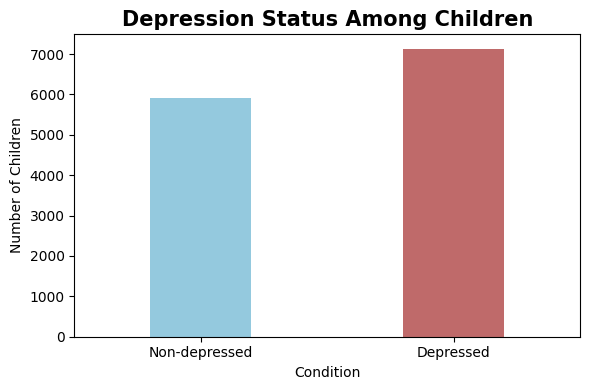

In [11]:
# Plot distribution of binary target variablt
plt2.bar_onevar(df)

### Determinants of Child Mental Health

<p style="text-align: justify;">
After preprocessing, we narrowed down the predictor variables into a final set of 12 variables across three levels: child, maternal, and household. The selection was based on data exploratory and their theoretical relevance to children's mental health outcomes in the context of Malawi.
</p>

#### Child-Level Variables
<p style="text-align: justify;">
<strong>1. Child's Age <code>CB3</code></strong>. A child's age essentially tells us where they are in that journey, and that has real implications for how mental health problems develop and present. Evidence also suggests that younger children tend to show higher risk for general behavioural and emotional problems, while older children and adolescents are more prone to internalising problems like anxiety and depression <a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC12198059/">[4]</a>.
</p>
<p style="text-align: justify;">
<strong>2. Child's Labour <code>CL2_cat</code></strong>. Child labour is pervasive across sub-Saharan Africa, and its consequences extend well beyond physical health. Child labour is associated with poor psychological health, deterioration of physical health, mental health problems, and lower socioeconomic opportunities in the long term. <a href="https://link.springer.com/article/10.1007/s00181-022-02241-5">[5]</a>
</p>
<p style="text-align: justify;">
<strong>3. Child's Household Tasks/Activities <code>CL12_cat</code></strong>. While light household chores can provide children with a sense of autonomy and responsibility, excessive or burdensome domestic work is a different matter entirely. Children who do not help with household chores were less likely to have high health satisfaction levels, to feel good when waking up, to be calm, or to have good self-affirmation. In contrast, excessive chores can lead to depressive symptoms in children as well as bullying behavior. In low-income settings like Malawi, household tasks often fall disproportionately on children and can interfere with schooling, rest, and play.<a href="https://psycnet.apa.org/doiLanding?doi=10.1037%2Fdev0000223">[6]</a>
</p>
<p style="text-align: justify;">
<strong>4. Learning Difficulty <code>FCF19_cat</code></strong>. Evidence suggests that children with learning disabilities are significantly more likely to develop internalising problems such as withdrawal and depressive symptoms compared to their peers, particularly when adequate support is not available <a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC10003319/?utm_source=chatgpt.com">[7]</a>
</p>
<table style="width:60%; border-collapse: collapse; margin: auto; text-align: center;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="border: 1px solid #ccc; padding: 8px;">Original Category</th>
      <th style="border: 1px solid #ccc; padding: 8px;">Recoded Label</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">No Difficulty</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="1">No Difficulty</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Some Difficulty</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="3">Has Difficulty</td>
    </tr>
     <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">A Lot of Difficulty</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Other</td>
    </tr>
    
  </tbody>
</table>
<p style="text-align: justify;">
<strong>5. Social Interaction <code>FCF24_cat</code></strong>. A child's ability to form and maintain social relationships is both a reflection of and a contributor to their mental health. Research consistently shows that children with limited social engagement are at higher risk of developing emotional and behavioural problems, making this variable an important indicator of children's psychological wellbeing <a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC8543788/?utm_source=chatgpt.com">[8]</a>.
</p>

#### Maternal-Level Variables
<p style="text-align: justify;">
<strong>6. Life Satisfaction Scale <code>LS1_cat</code>–<code>LS4</code></strong>. A mother's subjective sense of wellbeing is a meaningful predictor of the quality of care she provides. Life satisfaction captures a broader psychological state that may not be fully reflected by clinical measures of mental illness. Research consistently links poor maternal mental health and life satisfaction to worse child developmental and emotional outcomes, particularly in low- and middle-income countries.
</p>
<table style="width:60%; border-collapse: collapse; margin: auto; text-align: center;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="border: 1px solid #ccc; padding: 8px;">Original Category</th>
      <th style="border: 1px solid #ccc; padding: 8px;">Recoded Label</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Very Happy</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="2">Happy</td>
    </tr>
     <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Somewhat Happy</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Neither Happy nor Unhappy</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="3">Unhappy</td>
    </tr>
     <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Somewhat Unhappy</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Very Unhappy</td>
    </tr>
    
  </tbody>
</table>
<p style="text-align: justify;">
<strong>7. Marital Status <code>MSTATUS_cat</code></strong>. A mother's marital status shapes the social and economic resources available to her and her children. Children from single-parent families exhibit worse mental health outcomes than those from traditional families across multiple domains, including behavioural difficulties and quality of life. Single mothers face higher poverty risks and reduced parenting capacity, all of which can negatively affect child wellbeing. <a href="https://journals.sagepub.com/doi/full/10.1177/09731342231179017">[9]</a>
</p>
<table style="width:60%; border-collapse: collapse; margin: auto; text-align: center;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="border: 1px solid #ccc; padding: 8px;">Original Category</th>
      <th style="border: 1px solid #ccc; padding: 8px;">Recoded Label</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Currently Married/In Union</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="1">Currently Married</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Formerly Married/In Union</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="3">Not Married</td>
    </tr>
     <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Never Married/In Union</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Other</td>
    </tr>
    
  </tbody>
</table>
<p style="text-align: justify;">
<strong>8. Mother's Feels Safe Walking at Night <code>VT20_cat</code></strong>. A mother’s sense of safety in her neighbourhood reflects an important part of the child’s social environment. When mothers perceive their surroundings as unsafe, this may increase stress, limit wellbeing, and reduce the emotional and practical resources available for parenting. Research suggests that poorer neighbourhood conditions and lower maternal perceptions of neighbourhood safety are linked to worse child mental and behavioural outcomes, making this a relevant predictor of child depression. <a href="https://pubmed.ncbi.nlm.nih.gov/34590080/">[10]</a>
</p>
<table style="width:60%; border-collapse: collapse; margin: auto; text-align: center;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="border: 1px solid #ccc; padding: 8px;">Original Category</th>
      <th style="border: 1px solid #ccc; padding: 8px;">Recoded Label</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Very Safe</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="2">Safe</td>
    </tr>
     <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Safe</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Unsafe</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="3">Unsafe</td>
    </tr>
     <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Very Unsafe</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Never Walk Alone After Dark</td>
    </tr>
    
  </tbody>
</table>
<p style="text-align: justify;">
<strong>9. Mother's Experience of Discrimination <code>VT22_com</code></strong>. This variable captures whether the mother reported having personally experienced discrimination or harassment in the past 12 months on the basis of ethnicity, immigration origin, or sex. Maternal discrimination may affect child mental health by increasing psychological stress, reducing emotional wellbeing, and shaping a more insecure family environment. It was included because children’s emotional outcomes are often influenced not only by their own circumstances, but also by the stressors and social disadvantages experienced by their caregivers. <a href="https://pubmed.ncbi.nlm.nih.gov/37328141/">[11]</a>
</p>

#### Household-Level Variables
<p style="text-align: justify;">
<strong>10. Region <code>HH7_cat</code></strong>. Malawi has three main administrative regions, which are Northern, Central, and Southern, each with distinct socioeconomic profiles, access to services, cultural practices, and levels of poverty. Including region as a covariate helps control for these structural differences and prevents the model from conflating regional effects with individual-level risk factors.
</p>
<table style="width:60%; border-collapse: collapse; margin: auto; text-align: center;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="border: 1px solid #ccc; padding: 8px;">Original Category</th>
      <th style="border: 1px solid #ccc; padding: 8px;">Recoded Label</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">Central</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="1">Central</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">North</td>
      <td style="border: 1px solid #ccc; padding: 8px;" rowspan="2">Non Central</td>
    </tr>
     <tr>
      <td style="border: 1px solid #ccc; padding: 8px;">South</td>
    </tr>    
  </tbody>
</table>
<p style="text-align: justify;">
<strong>11. Wealth Index <code>wscore</code></strong>. Household wealth is one of the most robust and consistently documented determinants of child wellbeing. In Malawi specifically, economic instability, caused by events such as death of a family member, yield loss, or income loss, is positively associated with worse mental health outcomes. The wealth index, derived from asset ownership and household characteristics, provides a more stable and reliable proxy for socioeconomic status than income in this context.<a href="https://www.frontiersin.org/journals/psychology/articles/10.3389/fpsyg.2019.00819/full">[12]</a>
</p>
<p style="text-align: justify;">
<strong>12. Drinking Water Scarcity <code>WS7</code></strong>. Household access to sufficient drinking water is a basic indicator of living conditions and material security. When a household experiences drinking water shortages, this may reflect broader socioeconomic deprivation and increase daily stress for caregivers and children. For this reason, drinking water scarcity was included as a relevant household-level predictor of child depression.<a href="https://kclpure.kcl.ac.uk/portal/en/publications/evidence-on-the-links-between-water-insecurity-inadequate-sanitat/">[13]</a>
</p>

In [12]:
# Recode Marital Status
married_map = {
    'Currently married/in union' : 'Currently married',
    'Formerly married/in union' : 'Not married',
    'Never married/in union' : 'Not married',
    'Other' : 'Not married'
}

df['MSTATUS_cat'] = df['MSTATUS'].map(married_map)

# Recode bool variables (CL2 and CL12)
df['CL2_cat']  = np.where(df['CL2'], 'YES', 'NO')
df['CL12_cat'] = np.where(df['CL12'], 'YES', 'NO')

# Recode Difficulty
difficulty_map = {
    'NO DIFFICULTY' : 'NO DIFFICULTY',
    'SOME DIFFICULTY' : 'HAS DIFFICULTY',
    'A LOT OF DIFFICULTY' : 'HAS DIFFICULTY',
    'Other' : 'HAS DIFFICULTY'
}

df['FCF19_cat'] = df['FCF19'].map(difficulty_map)
df['FCF24_cat'] = df['FCF24'].map(difficulty_map)

# Recode Life Satisfaction
ls_map = {
    'VERY HAPPY' : 'happy',
    'SOMEWHAT HAPPY' : 'happy',
    'NEITHER HAPPY NOR UNHAPPY' : 'unhappy',
    'SOMEWHAT UNHAPPY' : 'unhappy',
    'VERY UNHAPPY' : 'unhappy'
}
df['LS1_cat'] = df['LS1'].map(ls_map)

# Recode mother feeling safe when walking in the neighborhood at night (VT20)
safety_map = {
    'VERY SAFE' : 'safe',
    'SAFE' : 'safe',
    'UNSAFE' : 'unsafe',
    'VERY UNSAFE' : 'unsafe',
    'NEVER WALK ALONE AFTER DARK' : 'unsafe'
}

df['VT20_cat'] = df['VT20'].map(safety_map)

# Merging variables: Mother ever felt discriminated due to ethnicity (VT22A) and Mother ever felt discriminated because of gender (VT22B)
df["VT22_com"] = np.where(
    (df["VT22A"] == "YES") | (df["VT22B"] == "YES"),
    "yes",
    "no"
)

# Recode Household Region
region_map = {
    'Central' : 'Central',
    'North' : ' Non Central',
    'South' : ' Non Central',
}
df['HH7_cat'] = df['HH7'].map(region_map)

# Select Required Feature
selected_features = [
    'CB3', 'CL2_cat', 'CL12_cat','FCF19_cat','FCF24_cat',#child
    'LS1_cat', 'MSTATUS_cat','VT20_cat','VT22_com', #maternal
    'HH7_cat', 'wscore','WS7' #household
]

### Missing Data Pattern

<p style="text-align: justify;">
Before proceeding with any modelling, we examined the extent and pattern of missing data across all selected variables. Understanding where and how much data is missing is important because different levels of missingness call for different handling strategies, and ignoring it entirely can introduce bias into the analysis.
</p>

<p style="text-align: justify;">
The percentage of missing values for each variable is shown in the figure below. Missing data is largely concentrated in maternal-level variables, while child-level and household-level variables are either complete or have negligible missingness. This pattern is consistent with the survey design, as not every child in the dataset had a fully completed maternal questionnaire.
</p>

<p style="text-align: justify;">
Looking at the individual variables, Mother Life Satisfaction (<code>LS1_cat</code>) and Mother Feel Safe Walking Alone at Night (<code>VT20_cat</code>) had the highest missingness at 2.29% and 2.27% respectively. The remaining variables, which are Learning Difficulty (<code>FCF19_cat</code>, 0.18%), Social Difficulty (<code>FCF24_cat</code>, 0.15%), Drinking Water Scarcity (<code>WS7</code>, 0.12%), and Mother Marital Status (<code>MSTATUS_cat</code>, 0.01%) had negligible missingness. Rather than removing rows, missing values were handled during preprocessing using a <code>ColumnTransformer</code> 
pipeline, with detailed prepropressing, numeric variables were imputed using the median, while categorical variables were imputed using the most frequent value. This approach preserves all observations and avoids data loss from listwise deletion.
</p>

<p style="text-align: justify;">
It is also worth noting that maternal variables tend to have slightly more missingness than others, likely because some mothers did not complete certain questions, potentially due to sensitive topics such as personal wellbeing or safety. This means the missing data may not be entirely random, which is a limitation we acknowledge when interpreting results later.
</p>

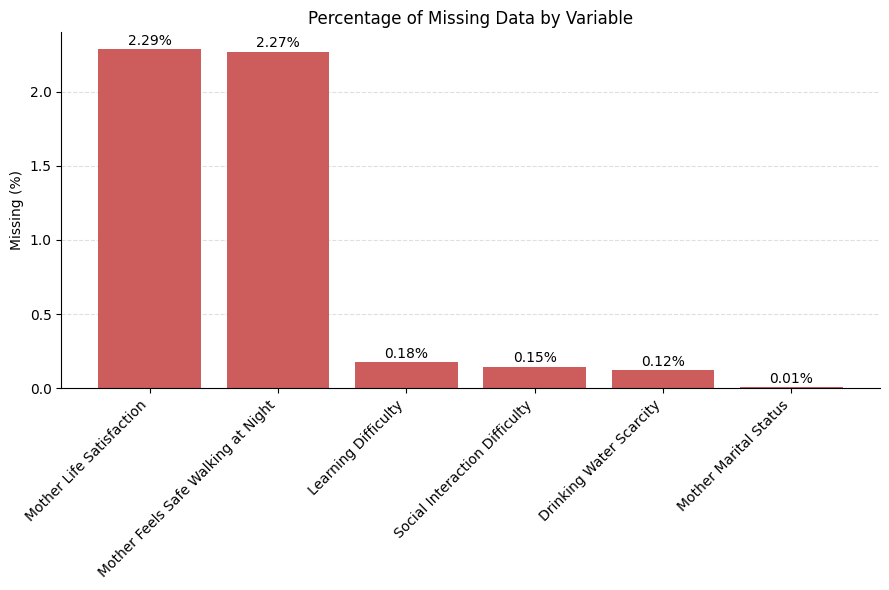

In [13]:
missing_val = ['NO RESPONSE', 'no response', '', ' ', 'NA', 'N/A', 'DK', 'MEMBERS DO NOT COLLECT']
missing_pct = plt2.plot_missing(df, selected_features, title_map=title_map, missing_val=missing_val)
df = df.replace(missing_val, np.nan)

### Data Preprocessing

<p style="text-align: justify;">
Before perfom modelling, we first split the data into training and test sets. This step was done before any preprocessing, fitting the pipeline on the full dataset would allow information from the test set to influence the preprocessing, making the model look better than it actually is. To avoid this, all imputation and scaling were fitted on the training data only. The final dataset had 13,036 observations and 12 features, split 80/20 into 10,428 training observations and 2,608 for testing. We also used stratified splitting to make sure both sets had a similar proportion of depressed and non-depressed cases, an important step given the imbalanced nature of our target variable.
</p>
<p style="text-align: justify;">
For preprocessing, we built a pipeline that treated numeric and categorical variables differently. The only numeric variable, Household Wealth Score, was imputed using the median and then standardised. The standardisation step is mainly there for Logistic Regression, as that model is sensitive to features being on very different scales.F or the categorical variables, missing values were filled using the most frequent category, followed by one-hot encoding to convert them into a numerical format the models can work with.
</p>


In [14]:
# Define X and Y final we used
X = df[selected_features].copy()
y = df['y'].copy()

print(f"Final sample size: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

Final sample size: 13036
Number of features: 12


In [15]:
# Splitting data into data training and data testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} observations")
print(f"Test set: {X_test.shape[0]} observations")

Training set: 10428 observations
Test set: 2608 observations


In [16]:
# Make preprocessing pipeline
# Identify numeric and categorical variables 
numeric_cols     = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('cleaner', NumericCleaner(outlier_method='iqr', skew_threshold=0.75)),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

### Association Between Child's Mental Health and Determinants

<p style="text-align: justify;">
The distribution of categorical variables by depression status is presented below, alongside Cramér's V as a measure of association strength between each categorical predictor and the depression outcome. All variables show weak associations with depression, as reflected by the low Cramér's V values ranging from 0.0473 to 0.1135. Mother Discriminated (Ethnicity or Gender) shows the strongest association (V = 0.1135), where children whose mothers experienced discrimination appear to have a noticeably higher proportion of depression compared to those who did not. Mother Life Satisfaction also shows a relatively meaningful association (V = 0.0976), suggesting that lower maternal life satisfaction is linked to a higher proportion of depression among children. Learning Difficulty (V = 0.0882) further indicates that children who have learning difficulties tend to have a higher proportion of depression compared to those without. Mother Feels Safe Walking at Night (V = 0.0473) and Social Interaction Difficulty (V = 0.0479) show the weakest associations among the retained variables. Nevertheless, the Chi-square test confirms that all variables are statistically significant (p < 0.05), indicating that each variable has a meaningful relationship with the depression outcome. All categorical predictors are therefore retained for inclusion in the model.
</p>

In [17]:
summary = plt2.contingency_table(df, categorical_cols, title_map)

                                  Variable   Chi2      p-value  Cramér's V
Mother Discriminated (Ethnicity or Gender) 167.96 2.067909e-38      0.1135
                  Mother Life Satisfaction 121.30 3.278638e-28      0.0976
                       Learning Difficulty 101.31 7.858509e-24      0.0882
                          Household Region  64.99 7.528663e-16      0.0706
                  Child Labour (Last Week)  63.39 1.696608e-15      0.0697
                   Drinking Water Scarcity  57.98 2.654355e-14      0.0667
                Child Household Activities  54.68 1.417587e-13      0.0648
                     Mother Marital Status  38.34 5.937623e-10      0.0542
             Social Interaction Difficulty  29.86 4.634310e-08      0.0479
        Mother Feels Safe Walking at Night  28.52 9.266257e-08      0.0473


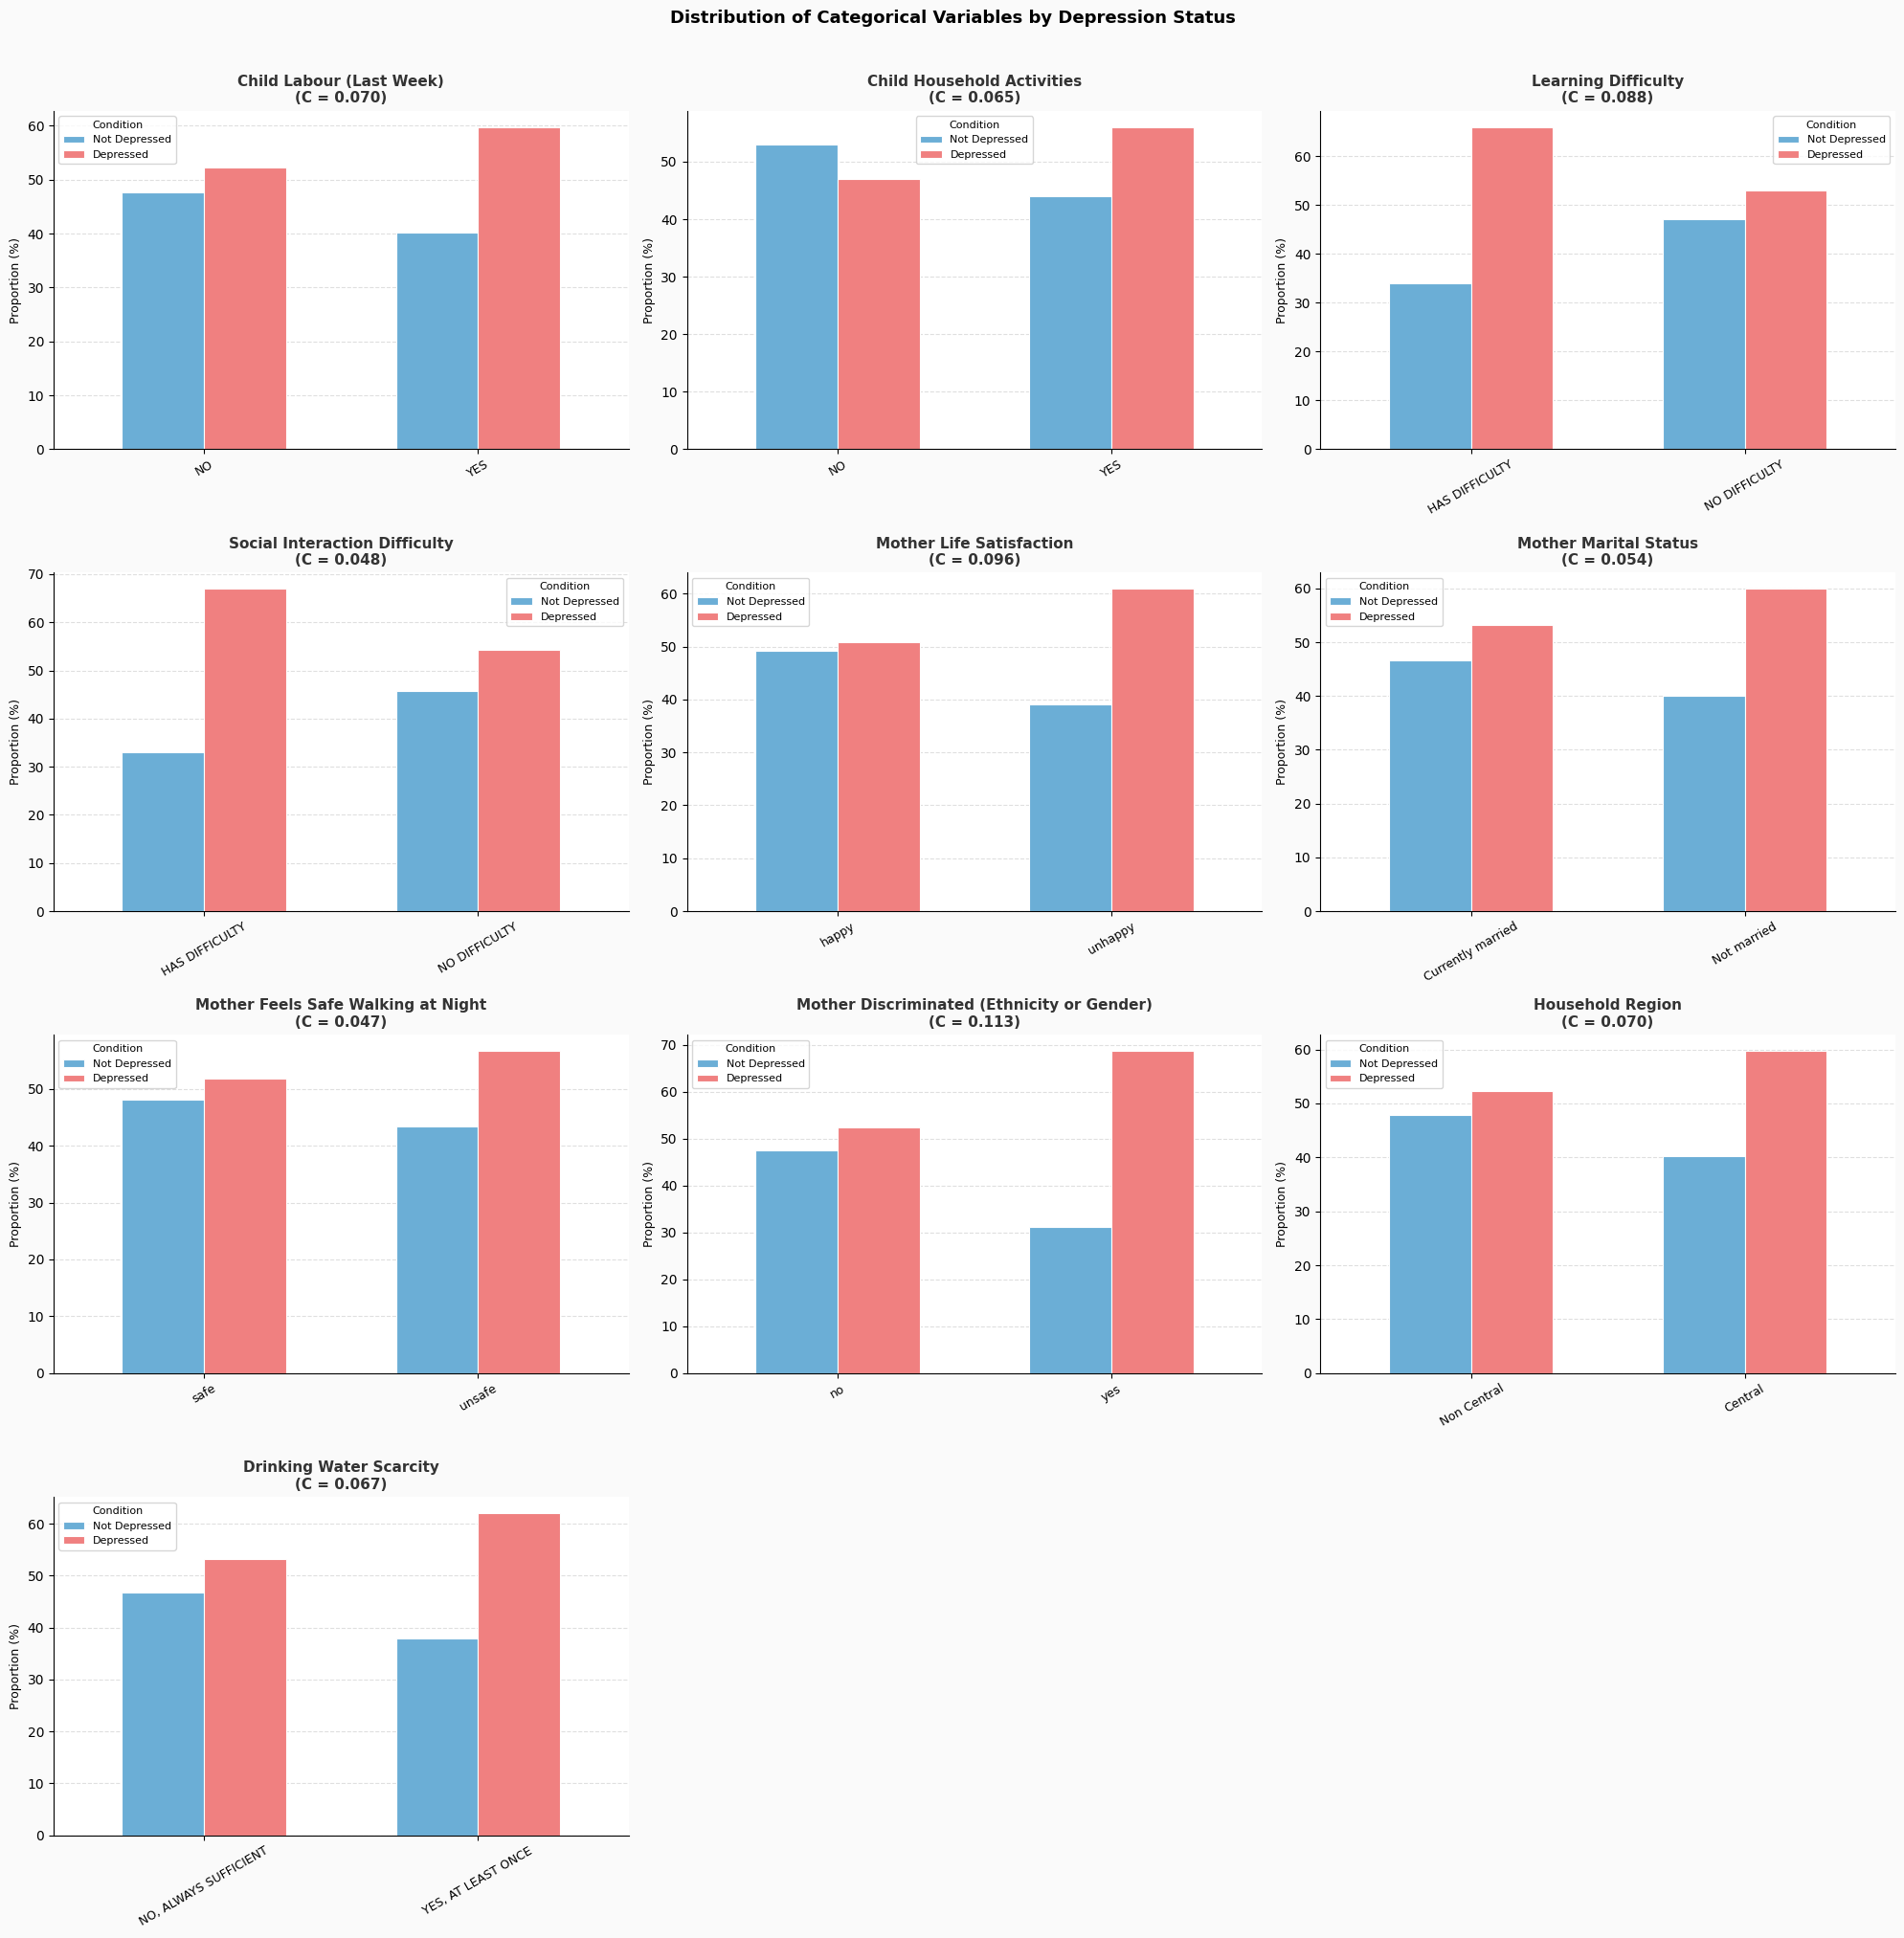

In [18]:
plt2.plot_categorical_vars(df, categorical_cols, title_map)

<div style="text-align: justify;">

The point biserial correlation was used to examine the relationship between numerical variables and depression status. Both variables show statistically significant but weak associations with depression (p < 0.001).

For Child's Age (r = 0.058), there is a small positive association, suggesting that older children tend to be slightly more likely to be depressed. This is visible in the boxplot where the median age of depressed children is around 10 years, compared to around 9 years for those not depressed. For Household Wealth Score (r = -0.058), there is a small negative association, indicating that children from wealthier households are slightly less likely to experience depression. The boxplots show largely overlapping distributions between the two groups, which is consistent with the weak correlation value.

</div>

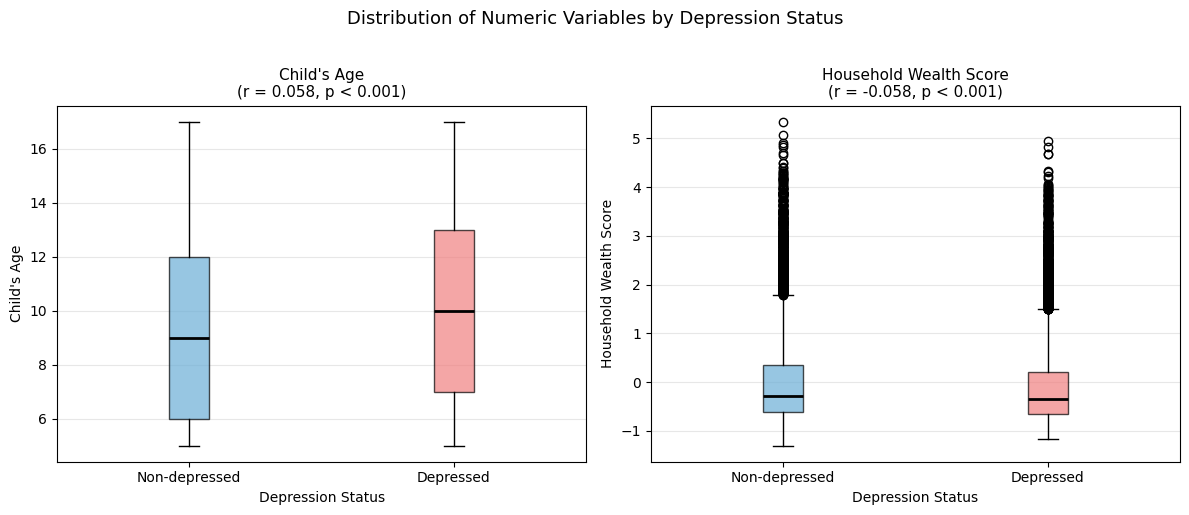

              Variable       r      p-value
           Child's Age  0.0576 4.559639e-11
Household Wealth Score -0.0577 4.176426e-11


In [19]:
summary_num = plt2.plot_numeric_vars(df, numeric_cols, target_col='y', title_map=title_map)

### Association Between Predictor Variables

<p style="text-align: justify;">
Before building the predictive model, it is important to examine whether the predictor variables (X) are associated with each other. Since the goal is to predict the child's mental health status, we expect each predictor to contribute independently as strong associations between predictors may cause redundancy and affect the reliability of the model.
</p>

<p style="text-align: justify;">
The heatmap shows that most variable pairs have associations close to 0, indicating that the predictors are largely independent from one another. The notable exceptions are Child's Age with Child Labour (Last Week) (0.39) and Child Household Activities (0.31), which is expected given that older children tend to be more involved in both activities. A modest association is also observed between Learning Difficulty and Social Interaction Difficulty (0.13), likely reflecting related developmental dimensions. The remaining variable pairs show associations at a low level, giving signal no serious multicollinearity concern. Therefore, the predictors are considered sufficiently independent and suitable for inclusion in the model.
</p>

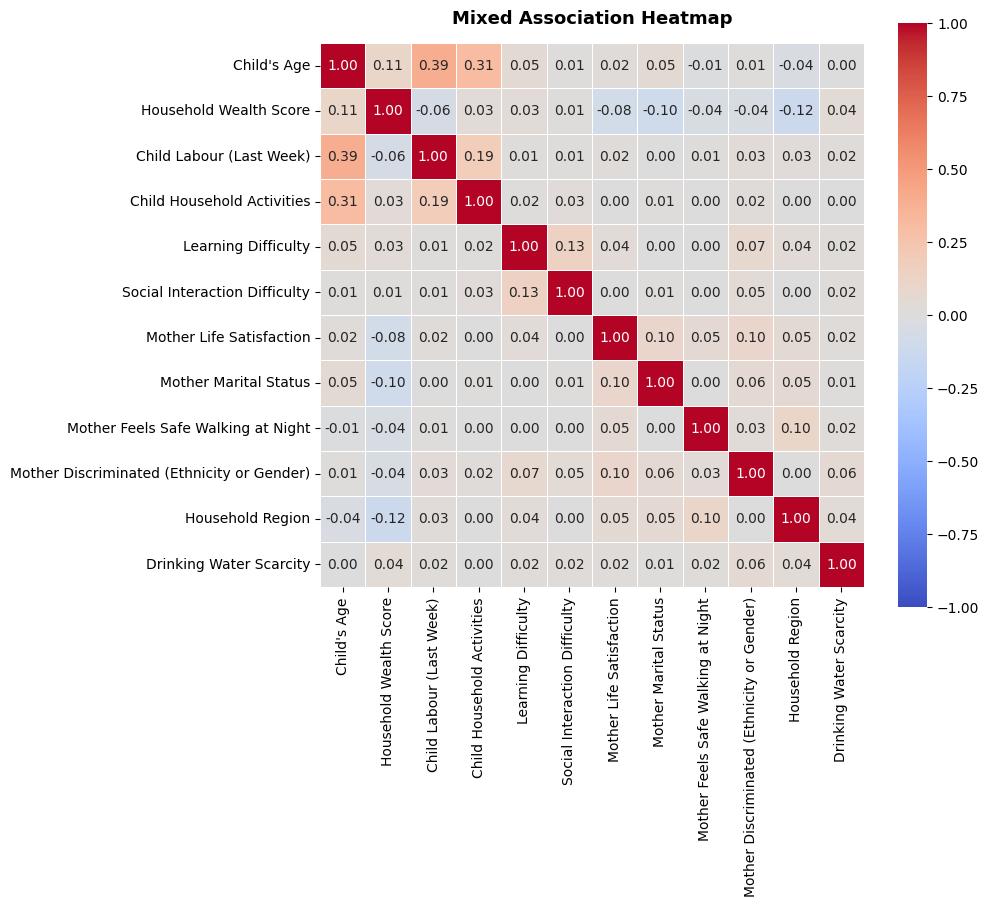

In [20]:
all_cols = numeric_cols + categorical_cols 
result = plt2.mixed_correlation_heatmap(df, cols=all_cols, label_map=title_map,
                                   binary_maps=None, title="Mixed Association Heatmap")

## **Model Fitting and Tuning**

### Framework Association between Child's mental health and its determinants

<p style="text-align: justify;">
Based on the exploratory analysis conducted in the preceding sections, the final set of predictor variables retained for the model is presented in the framework below. These variables span three levels of influence: child, maternal, and household, each of which has been identified as theoretically and empirically relevant to children's mental health outcomes in the Malawian context.
</p>

<p style="text-align: justify;">
At the child level, the final predictors include Child Age, Child Labour (Last Week), Child Household Activities, Learning Difficulty, and Social Interaction Difficulty. At the maternal level, Mother's Life Satisfaction, Mother's Marital Status, Mother Feels Safe Walking at Night, and Mother Discriminated (Ethnicity or Gender) are included. At the household level, Household Region, Household Wealth Score, and Drinking Water Scarcity are retained. Taken together, these 12 variables form the final analytical framework for predicting child mental health outcomes, specifically persistent and non-persistent depression, in this study.
</p>
<p style="text-align: justify;">
Forward feature selection from a broader pool of candidate variables identified several additional predictors (e.g., ethnicity, maternal life satisfaction ladder, household assets). However, their inclusion improved cross‑validated performance only marginally (ΔAUC = +0.016, ΔF1 < 0.01) and did not substantively change the estimated effects of the core theoretical predictors. Given the modest gains and the risk of overfitting, we retain the theory‑driven 12‑feature model as our primary specification. Results from the augmented model are available upon request and confirm the robustness of the main findings.
</p>

```mermaid
flowchart LR
    subgraph CL["Child Level"]
        direction TB
        C1[Child Labour Last Week]
        C2[Child Household Activities]
        C3[Learning Difficulty]
        C4[Social Interaction Difficulty]
        C5[Age]
    end

    subgraph ML["Maternal Level"]
        direction TB
        M1[Mother Life Satisfaction]
        M2[Mother Marital Status]
        M3[Mother Feels Safe Walking at Night]
        M4[Mother Discriminated Ethnicity or Gender]
    end

    subgraph HL["Household Level"]
        direction TB
        H1[Household Region]
        H2[Household Wealth Score]
        H3[Drinking Water Scarcity]
    end

    subgraph OUT["Target Variable"]
        direction TB
        Y[Child Mental Health Depression Status]
    end

    CL --> OUT
    ML --> OUT
    HL --> OUT
```

### Methods Selection

<p style="text-align: justify;">
This study employs two classification approaches to predict child depression status, which are Logistic Regression and CatBoost. These two methods were selected to complement each other, as they represent different modelling philosophies that together offer both interpretability and predictive performance.
</p>

<p style="text-align: justify;">
Logistic Regression serves as the baseline model in this study. Given that the outcome variable is binary in nature. Logistic regression is a natural and well-established choice for this type of classification problem. Beyond its suitability for binary outcomes, logistic regression offers a high degree of interpretability, as the estimated coefficients can be directly translated into odds ratios, allowing for a clearer understanding of the direction and magnitude of each predictor's relationship with the outcome. This is particularly valuable in a public health context, where communicating findings to a broader audience requires transparency and clarity in how conclusions are drawn.
</p>

<p style="text-align: justify;">
CatBoost was selected as the second model due to its strength in handling datasets that contain a large proportion of categorical variables, which is characteristic of the dataset used in this study. Unlike many other gradient boosting algorithms that require extensive preprocessing such as one-hot encoding, CatBoost natively processes categorical features through an ordered target statistics approach, reducing the risk of data leakage during training. Furthermore, CatBoost has demonstrated strong predictive performance on structured tabular data, often outperforming other ensemble methods with minimal hyperparameter tuning. Its built-in mechanisms for handling class imbalance and its robustness to overfitting further make it a suitable candidate for this classification task.
</p>

<p style="text-align: justify;">
By combining a transparent baseline model with a high-performing ensemble method, this study aims to not only achieve reliable predictions but also retain the ability to interpret and communicate the findings in a meaningful way.
</p>

### ***1. Logistic Regression with Regularisation***

<p style="text-align: justify;">
A baseline logistic regression model was used for binary classification of depression status. Numerical variables were imputed using the median and standardised, while categorical variables were imputed using the most frequent category and one-hot encoded through a preprocessing pipeline. Hyperparameters, including the L2 regularisation strength (C) and class weights, were tuned using 5-fold stratified cross-validation. L2 regularisation was selected as the penalty type to ensure all features contributed to the model while preventing overfitting through coefficient shrinkage. Because the primary objective of the study was to minimize missed cases of depression in children, Recall was utilized as the main optimisation metric to maximize the identification of true positive cases.
</p>


In [21]:
def to_dense(X):
    if sp.issparse(X):
        return X.toarray() #to convert the sparse matrix to dense format
    return X

# Make Baseline model with preprocessor pipeline defined in previous section
baseline_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        solver='liblinear',
        random_state=42
    ))
])
# Hyperparameter tuning using 5-fold cross validation
# Searching over L2 regularisation types and regularisation strength C
param_grid = {
    'model__penalty': ['l2'],
    'model__C': [0.01, 0.1, 1, 10],
    'model__class_weight': [
        None,
        'balanced',
        {0: 1, 1: 1.5} # custom weights to further penalise false negatives
    ]
}

# using stratified k-fold to maintain class balance in folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV to find best hyperparameters based on recall score
grid = GridSearchCV(
    estimator=baseline_pipe,
    param_grid=param_grid,
    scoring='recall', # to minimise false negatives (missing depressed children)
    cv=cv,
    n_jobs=-1,
    verbose=0 # set to 0 for cleaner report output
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV Recall:", round(grid.best_score_, 4))

# get the best model from grid search
best_baseline = grid.best_estimator_

# Top 10 most influential features by absolute coefficient value
feature_names = best_baseline.named_steps['preprocessor'].get_feature_names_out()
coef = best_baseline.named_steps['model'].coef_[0]

Best parameters: {'model__C': 0.01, 'model__class_weight': {0: 1, 1: 1.5}, 'model__penalty': 'l2'}
Best CV Recall: 0.9667


<p style="text-align: justify;">
The best-performing configuration used L2 regularisation with C = 0.01 and a class weight of {0:1, 1:1.5}, achieving a cross-validation recall score of 0.9667. While this suggests the model perfectly identified all depressed children across folds, it should be interpreted cautiously as it may reflect overfitting to the training folds. To improve the balance between sensitivity and precision on unseen data, predicted probabilities were converted into class labels across a range of candidate thresholds, and the threshold yielding the highest recall among those with precision of at least 0.60 was selected, resulting in a chosen threshold of 0.588.
</p>

<p style="text-align: justify;">
At this threshold, the model achieved an accuracy of 0.5951, an F1-score of 0.6763, and a ROC–AUC of 0.6164 on the test set. For the depressed group (class 1), the model achieved a precision of 0.60 and a recall of 0.77, correctly identifying approximately 77% of depressed children, though at the expense of a high number of false positives. For the non-depressed group (class 0), performance was weaker, with a precision of 0.58 and a recall of 0.38, indicating that a large proportion of non-depressed children were misclassified as depressed. The confusion matrix confirms this pattern, with 1103 true positives and 449 true negatives, against 324 false negatives and 732 false positives.
</p>

<p style="text-align: justify;">
The threshold tuning curve illustrated the expected trade-off, where increasing the threshold reduced recall while gradually improving precision, with the F1-score peaking around 0.588. The precision-recall curve further supported this, with an average precision (AP) score of 0.660, indicating moderate discriminative performance. Overall, the model demonstrated a reasonable ability to detect depressed children while maintaining moderate precision, which is an acceptable trade-off in this context given that missing depressed children carries a higher cost than over-identifying them.
</p>

Chosen threshold: 0.5880000000000004


threshold             0.588000
precision             0.601090
recall                0.772950
f1                    0.676272
false_negatives     324.000000
false_positives     732.000000
true_negatives      449.000000
true_positives     1103.000000
Name: 488, dtype: float64


=== Logistic Regression with Tuned Threshold ===
Chosen threshold : 0.588
Accuracy         : 0.5951
F1-score         : 0.6763
ROC-AUC          : 0.6164

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.38      0.46      1181
           1       0.60      0.77      0.68      1427

    accuracy                           0.60      2608
   macro avg       0.59      0.58      0.57      2608
weighted avg       0.59      0.60      0.58      2608



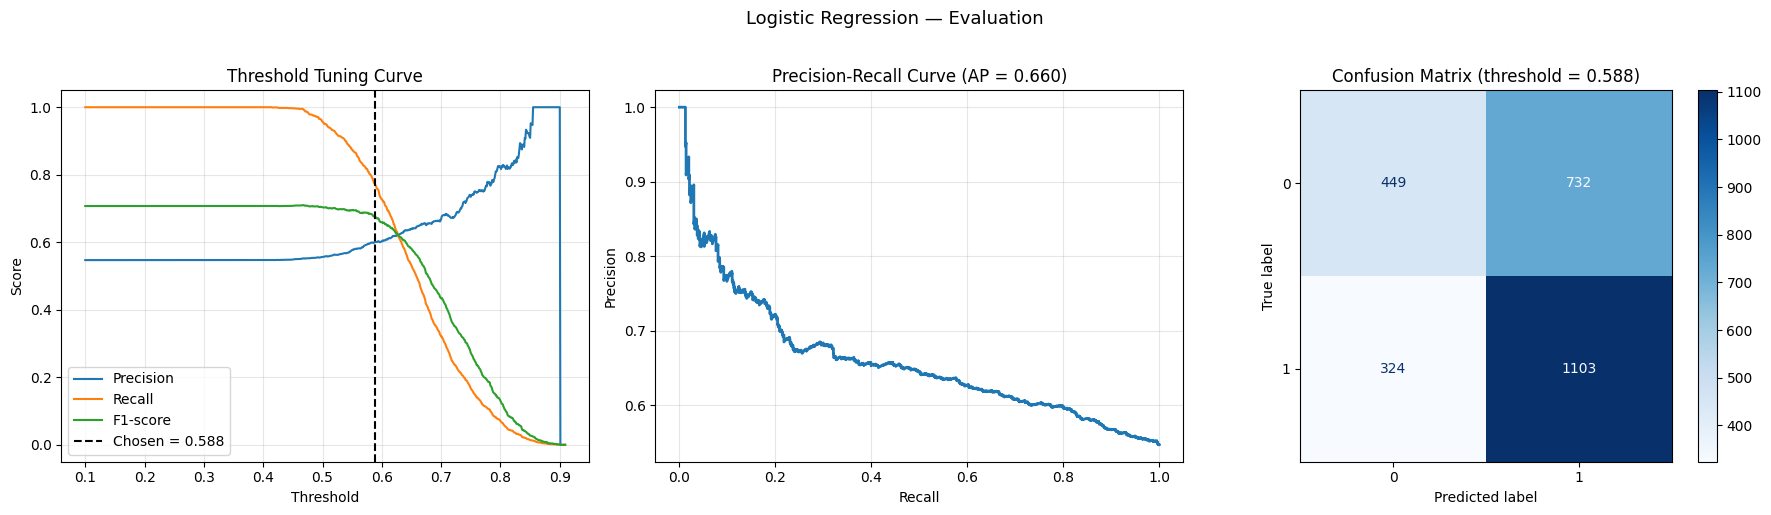

In [22]:
threshold_results_base, best_threshold, y_pred_base_tuned = tune_threshold(
    best_baseline, X_test, y_test, model_name="Logistic Regression"
)

### ***2. Gradient Boosting Decision Tree Using CatBoost Classifier***

<p style="text-align: justify;">
An alternative CatBoost classifier was used for binary classification of depression status. The same preprocessing pipeline was applied, including median imputation and standardisation for numerical variables, and most-frequent imputation with one-hot encoding for categorical variables. As one-hot encoding generated a sparse matrix, the transformed data were converted to dense format before being passed to CatBoost. Hyperparameters, including tree depth, learning rate, number of iterations, L2 regularisation, and class-weight settings, were tuned using 5-fold stratified cross-validation. Recall was again used as the primary optimisation metric to minimise false negatives.
</p>

In [23]:
# since we use onehot encoding, the output of preprocessor is a sparse matrix which is not compatible with CatBoost
# we need to convert it to dense format before passing it into CatBoost

# making alternative model using catboost with preprocessor pipeline defined in previous section
catboost_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('to_dense', FunctionTransformer(to_dense, accept_sparse=True)),
    ('model', CatBoostClassifier(
        loss_function='Logloss',
        random_state=42,
        verbose=0
    ))
])


# Hyperparameter tuning using 5-fold cross validation
# Searching over depth, learning rate, number of iterations, and L2 regularisation strength
param_grid_cat = {
    'model__depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.1],
    'model__iterations': [200, 500],
    'model__l2_leaf_reg': [1, 3, 5],
    'model__auto_class_weights': ['Balanced', 'SqrtBalanced']  # removed None
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_cat = GridSearchCV(
    estimator=catboost_pipe,
    param_grid=param_grid_cat,
    scoring='recall', # to minimise false negatives (missing depressed children)
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid_cat.fit(X_train, y_train)

print("Best parameters:", grid_cat.best_params_)
print("Best CV Recall:", round(grid_cat.best_score_, 4))

# get the best model from grid search
best_catboost = grid_cat.best_estimator_

# Top 10 most influential features
feature_names = best_catboost.named_steps['preprocessor'].get_feature_names_out()
importances = best_catboost.named_steps['model'].get_feature_importance()


Best parameters: {'model__auto_class_weights': 'SqrtBalanced', 'model__depth': 4, 'model__iterations': 200, 'model__l2_leaf_reg': 5, 'model__learning_rate': 0.01}
Best CV Recall: 0.6467


<p style="text-align: justify;">
The best-performing CatBoost configuration used a depth of 4, a learning rate of 0.01, 200 iterations, L2 leaf regularisation of 5, and SqrtBalanced automatic class weighting, achieving a cross-validation recall score of 0.6467. Unlike the logistic regression, the CatBoost model did not show signs of overfitting during cross-validation, suggesting a more stable generalisation to unseen data. Similarly, predicted probabilities were converted into class labels across a range of candidate thresholds, and the threshold yielding the highest recall among those with precision of at least 0.60 was selected, resulting in a chosen threshold of 0.482. A precision floor of 0.60 was chosen to balance sensitivity with follow‑up resource constraints. In a screening context, this ensures that at least three in five children flagged for further assessment are true cases, limiting over‑referral while still distinguishing most children experiencing depressive symptoms.
</p>

<p style="text-align: justify;">
At this threshold, the CatBoost model produced 1091 true positives and 456 true negatives, against 336 false negatives and 725 false positives. For the depressed group (class 1), the model achieved a recall of approximately 0.76, correctly identifying the majority of depressed children, though again at the expense of a notable number of false positives. For the non-depressed group (class 0), performance remained limited, with a considerable proportion of non-depressed children misclassified as depressed, consistent with the class imbalance challenge in this dataset.
</p>

<p style="text-align: justify;">
The threshold tuning curve illustrated the same expected trade-off as the logistic regression, where increasing the threshold reduced recall while gradually improving precision, with the F1-score peaking around 0.482. The precision-recall curve yielded an average precision (AP) score of 0.653, which is marginally lower than that of the logistic regression (0.660), indicating comparable discriminative performance between the two models. Given the similarity in performance and the superior interpretability of logistic regression, the logistic regression model was ultimately selected as the final model for this study.
</p>

Chosen threshold: 0.4820000000000003


threshold             0.482000
precision             0.600771
recall                0.764541
f1                    0.672834
false_negatives     336.000000
false_positives     725.000000
true_negatives      456.000000
true_positives     1091.000000
Name: 382, dtype: float64


=== CatBoost with Tuned Threshold ===
Chosen threshold : 0.482
Accuracy         : 0.5932
F1-score         : 0.6728
ROC-AUC          : 0.6138

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.39      0.46      1181
           1       0.60      0.76      0.67      1427

    accuracy                           0.59      2608
   macro avg       0.59      0.58      0.57      2608
weighted avg       0.59      0.59      0.58      2608



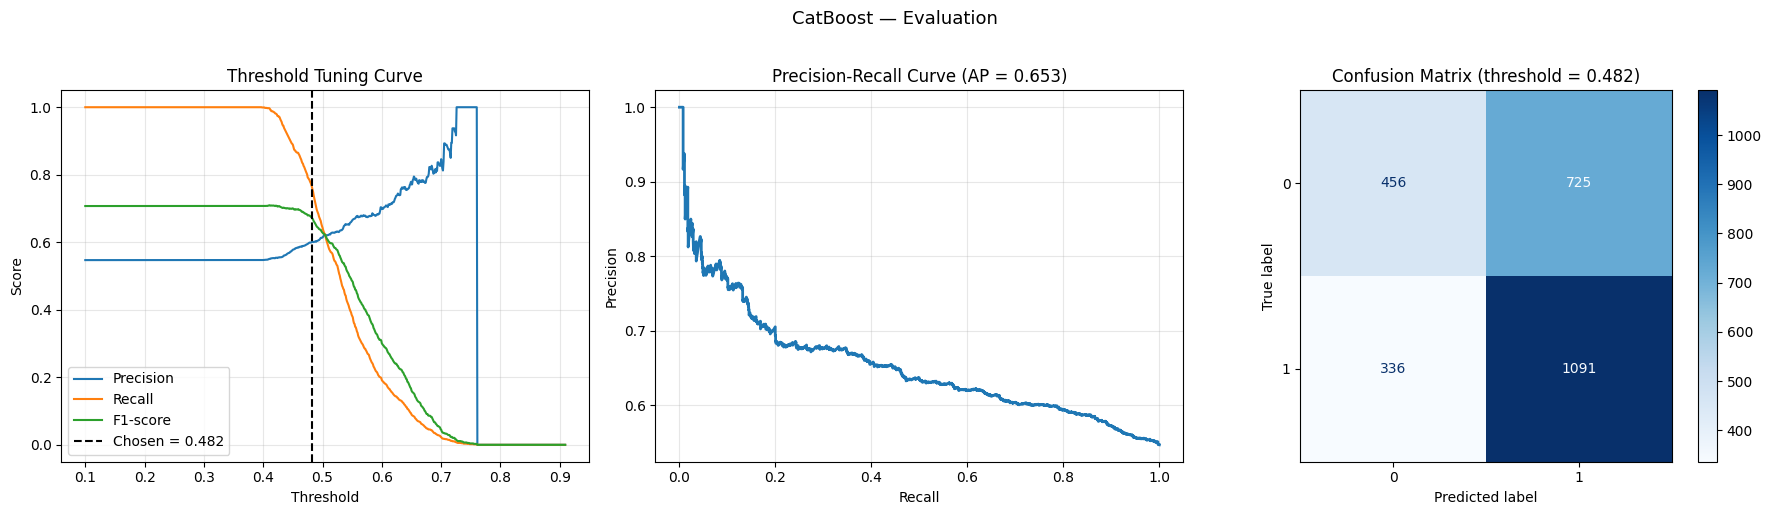

In [ ]:
threshold_results_cat, best_threshold_cat, y_pred_cat_tuned = tune_threshold(
    best_catboost, X_test, y_test, model_name="CatBoost" )

<p style="text-align: justify;">
Both logistic regression and CatBoost achieved comparable predictive performance, with CatBoost offering only marginal differences in discriminative ability (AP = 0.653 vs. 0.660). This suggests that the underlying relationships between the predictors and depression outcome are relatively linear in nature, with limited complex non-linear structure for a more powerful model to exploit. Given this parity in performance, logistic regression was selected as the final model due to its superior interpretability and computational efficiency, which are particularly valuable in a public health context where understanding the drivers of depression is as important as prediction itself.
</p>

<p style="text-align: justify;">
Nevertheless, overall predictive performance remains modest, with a ROC-AUC of approximately 0.615, indicating that the available features provide limited discriminatory power. This is further reflected in the recall and precision values, suggesting that a substantial proportion of depressed children remain undetected and that false positives are frequent. These limitations likely stem from the complexity of childhood depression as a condition influenced by unmeasured psychological, social, and contextual factors that are not fully captured by the available survey variables. Despite these constraints, the logistic regression model provides a reasonable and interpretable foundation for identifying key risk factors, which will be explored in the following section.
</p>

## Result
<p style="text-align: justify;">
Analysis of the logistic regression coefficients identifies several critical determinants of childhood depression in Malawi. The strongest positive predictor is the mother’s experience of discrimination based on ethnicity or sex (0.355), which, when paired with maternal unhappiness (0.246), suggests that maternal well-being and the immediate caregiving environment are central to a child’s psychological risk. At the child level, a distinct pattern of burden emerges: learning difficulties (0.280), child labor (0.209), involvement in household activities (0.205), social interaction difficulty (0.196), and child age (0.065) increase the likelihood of depression. Furthermore, geographical and structural stressors play a major role, specifically drinking water scarcity (0.247) and residence in the Central region (0.229). Social instability is evidenced by maternal safety concerns in the neighborhood (0.168) and non-married status (0.191) further compounds this risk. Notably, household wealth emerged as the sole protective factor (-0.068), indicating that higher socioeconomic status provides a modest buffer against depression. Collectively, these findings suggest that childhood depression is a multifaceted issue driven by a combination of maternal distress, labor-related burdens, and systemic resource deprivation.
</p>

<p style="text-align: justify;">
The permutation importance results validate the practical utility of the model by highlighting the features most critical for maintaining high Recall. Household Region emerges as the most influential predictor since its randomisation causes the most drop in the model's ability to identify depressed children, reinforcing the geographical disparities noted in the coefficient analysis. This is followed closely by Drinking Water Scarcity and Child Household Activities, confirming that resource deprivation and child-level labor are not merely correlated with depression but are essential signals for the model's predictive accuracy.
</p>

<p style="text-align: justify;">
Furthermore, Child’s Age, Child Labor, and Household Wealth provide meaningful discriminatory power, suggesting these factors are stable indicators of risk. Interestingly, while Social Interaction Difficulty and Learning Difficulty showed strong positive associations in the coefficient analysis, their lower (and in some cases, slightly negative) permutation importance suggests that their predictive contribution may be partially redundant when geographical and household stressors are already present in the model. In contrast, Mother’s Marital Status, Life Satisfaction, and Discrimination also exhibit negative importance, indicating they provide less unique predictive value for this specific classification threshold. In summary, the results emphasize that geography, household hardship, and physical child burden are the most reliable pillars for identifying at-risk children in the Malawian context.
</p>

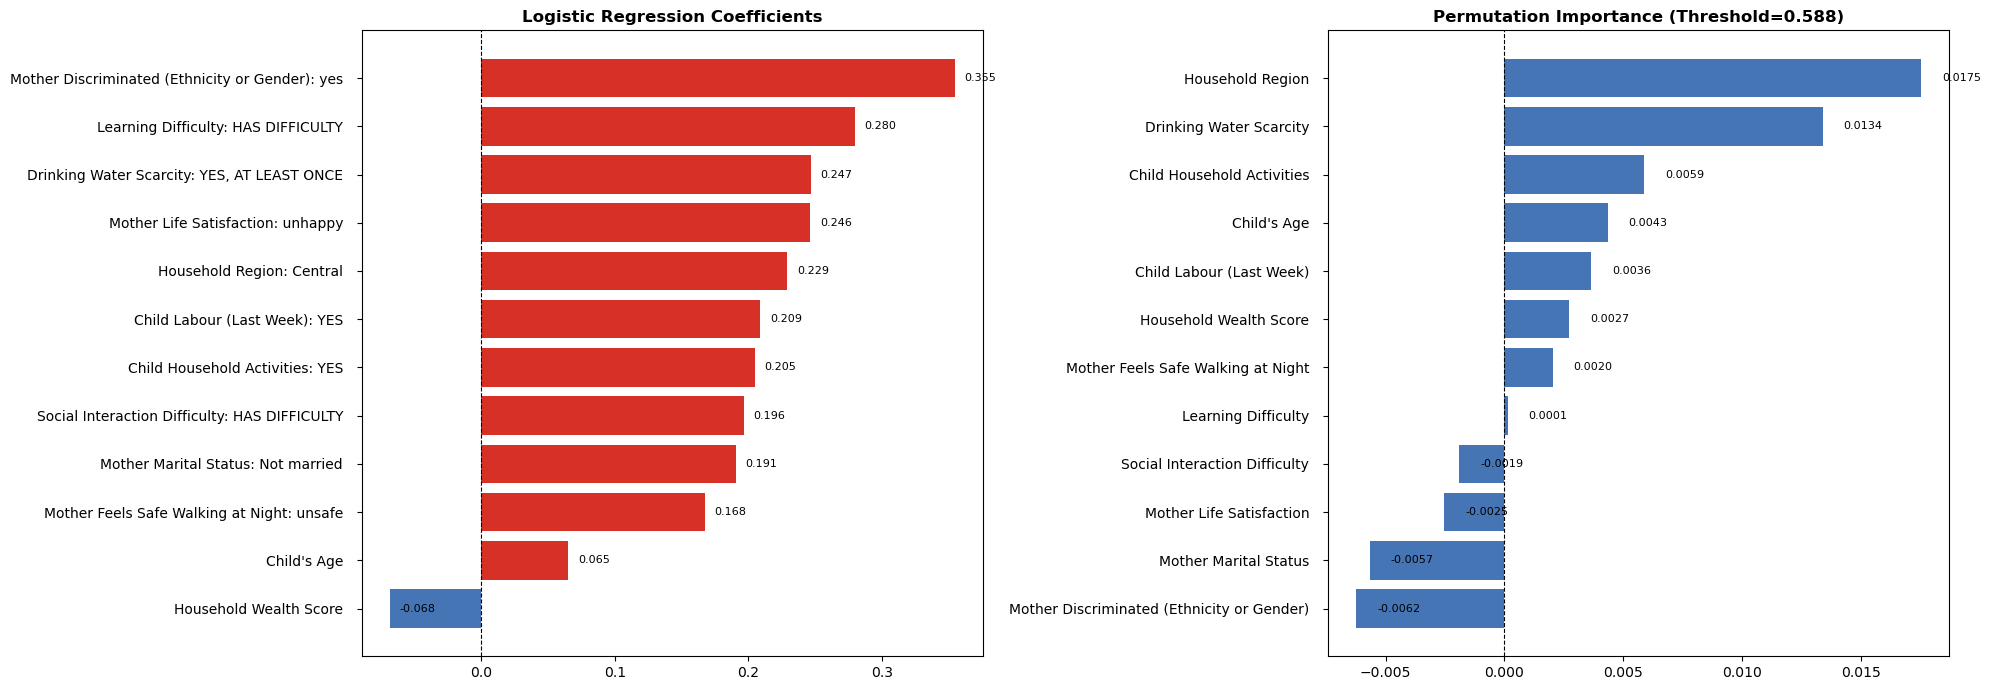

In [186]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Coefficients
plot_coefficients(best_baseline, title_map=title_map, ax=ax1)

# Plot 2: Permutation Importance
plot_permutation_importance(best_baseline, X_test, y_test, title_map=title_map, threshold=best_threshold, ax=ax2)

plt.tight_layout()
plt.show()

<p style="text-align: justify;">
The SHAP (SHapley Additive exPlanations) beeswarm plot provides a granular look at how the model arrives at its predictions. Each point represents an individual child in the dataset. The horizontal axis measures the SHAP value, representing the impact on the model's output: points to the right of the center line indicate factors that increase the probability of a depression diagnosis, while points to the left decrease it. The color scale indicates the feature value, where red signifies "high" (e.g., the presence of a condition or higher numerical value) and blue signifies "low".
</p>
<p style="text-align: justify;">
The analysis reveals that maternal wellbeing and social experiences are the most influential drivers of the model. Specifically, maternal unhappiness (LS1) and maternal experiences of discrimination (VT22) show strong positive SHAP values, meaning their presence significantly pushes the model toward a depression prediction. Similarly, environmental and structural factors such as living in the Central region (HH7), experiencing drinking water scarcity (WS7), and mothers feeling unsafe at night (VT20) and maternal marital status (MSTATUS) act as consistent risk indicators, shifting individual predictions to the right.
</p>
<p style="text-align: justify;">
The plot also highlights the "burden" placed on children as a contributor to psychological distress. The presence of child labor (CL2) and heavy household activities (CL12) are clearly associated with increased risk, as are child-level difficulties with learning and social interaction (FCF19 and FCF24). Furthermore, the model identifies child age (CB3) as an incremental risk factor, with older children showing a higher propensity for depression than their younger counterparts.
</p>
<p style="text-align: justify;">
Lastly, the Household Wealth Score (wscore) stands out as the most distinct protective factor. Unlike the other predictors, high wealth (red) is concentrated on the left side of the axis, indicating a strong negative impact on the depression probability. Conversely, low wealth (blue) correlates with increased risk. In summary, the SHAP results demonstrate that while individual and maternal factors are primary triggers, they exist within a broader framework of socioeconomic status and regional resource access that ultimately dictates the child's risk profile.
</p>

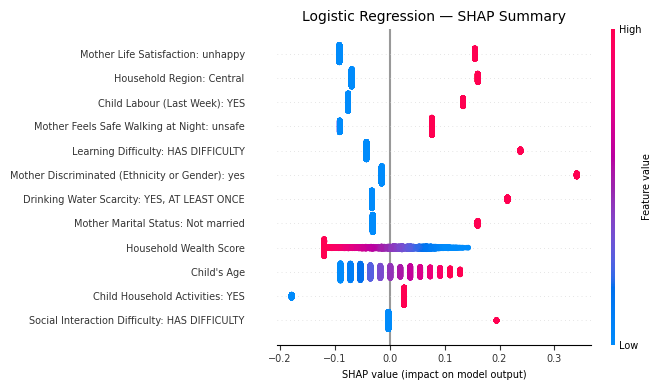

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
shap_vals_lr, shap_names_lr = plot_shap(
    best_baseline, X_train, X_test,
    title_map=title_map,
    ax=ax
)

plt.title("Logistic Regression — SHAP Summary",fontsize=10)
plt.tight_layout()
plt.show()

## Conclusion

<p style="text-align: justify;">
Across all analyses, the results consistently point to the same message: childhood depression in Malawi is rarely caused by one thing alone. It tends to occur among children who are already living in difficult circumstances, where multiple pressures are present at the same time. The key takeaways are as follows:
</p>

<ul>
<li><p style="text-align: justify;">Where a child lives matters. Children from the Central region and households without reliable access to clean water were more likely to be identified as depressed. This may be because these areas tend to face greater poverty and limited access to public services, creating a stressful and unstable environment for children to grow up in.</p></li>

<li><p style="text-align: justify;">Children who carry too much are more at risk. Children involved in household chores, child labour, or those experiencing learning or functional difficulties showed higher rates of depression. When children are overburdened with responsibilities or struggle to keep up at school, it leaves little room for healthy development and emotional wellbeing.</p></li>

<li><p style="text-align: justify;">A mother's wellbeing affects her child's. Children whose mothers were unhappy, felt discriminated against, or reported low life satisfaction were more likely to be depressed. Mothers who are struggling emotionally may have less capacity to provide the warmth, stability, and support that children need to thrive.</p></li>

<li><p style="text-align: justify;">Wealthier households offer some protection. Higher household wealth was the one factor consistently linked to lower depression risk. Families with more financial resources are better placed to meet their children's basic needs, reduce daily stress, and access support when needed.</p></li>

<li><p style="text-align: justify;">Not all factors were equally useful. Some variables, such as mother's marital status and social interaction difficulty, turned out to have little practical value in identifying depressed children, even if they showed statistical associations earlier.</p></li>
</ul>

<p style="text-align: justify;"> Beyond identifying these risk factors, the logistic regression model developed in this study demonstrated practical utility as a screening tool. On the held‑out test set, the model achieved a recall of 77% and a precision of 60% (F1 = 0.68, ROC‑AUC = 0.61). In operational terms, this means that a screening programme based on this model could correctly identify more than three‑quarters of children experiencing depressive symptoms, while ensuring that three in every five children flagged for follow‑up are true cases. This balance limits the over‑burdening of mental health resources while still capturing the large majority of at‑risk children. </p>
<p style="text-align: justify;"> The more complex alternative CatBoost produced nearly identical performance (recall of 76% and 74%, respectively; AUC ≈ 0.61). The convergence of these models indicates that the predictive ceiling of the available MICS data had been reached and that the simpler, more interpretable logistic regression is the most appropriate choice. </p>
<p style="text-align: justify;">
These results also align well with the broader literature. A large‑scale study of Chinese children found logistic regression to perform comparably to or better than more complex models (recall = 0.72, AUC = 0.83) <a href="https://pubmed.ncbi.nlm.nih.gov/41265655/">[15]</a>. Validation work in Sub‑Saharan Africa has demonstrated that depression screening tools can achieve strong discriminative performance (AUC 0.79–0.89) <a href="https://khub.africacdc.org/public/515396b0-d603-4fc9-9bff-5cb3488059a8">[16]</a>, and a systematic review of screening scales reported a pooled sensitivity of 0.80 <a href="https://doi.org/10.1016/j.jad.2014.11.061">[17]</a>. The present model, despite relying only on routinely collected MICS indicators, therefore demonstrates feasibility comparable to established screening instruments.
</p>
<p style="text-align: justify;"> Taken together, these findings suggest that tackling childhood depression in Malawi requires looking beyond the child alone. The conditions at home, the pressures placed on children, and the wellbeing of their mothers all matter. Targeted support for the most vulnerable households could go a long way in reducing depression risk among children. </p>

## Limitation and Future Work

<p style="text-align: justify;">
Several limitations should be acknowledged. First, the cross‑sectional MICS data preclude causal inference; associations cannot be interpreted as causal effects. Second, the outcome relies on caregiver‑reported sadness, a subjective proxy that may not align with clinical diagnoses and is subject to reporting bias. Third, important determinants, such as peer relationships, school climate, and trauma exposure, are not captured in the survey, introducing potential omitted variable bias. Fourth, missing data in maternal‑level variables were handled via simple imputation, which may underestimate uncertainty. Finally, the model was developed on Malawi MICS round 6 data; generalizability to other settings requires external validation.
</p>

<p style="text-align: justify;">
Future research could validate these risk factors in other MICS countries or more recent survey rounds to assess robustness across contexts. The introduction of enhanced mental health modules in MICS (e.g., MMAPP <a href="https://mics.unicef.org/news/new-mics-module-measure-mental-health-adolescents-and-young-people">[14]</a>) may provide richer outcomes and improve predictive performance. More sophisticated missing‑data techniques, such as multiple imputation, could better account for uncertainty. Integrating external data sources (e.g., community infrastructure or geospatial indicators) may capture additional dimensions of children's environments. Finally, the identified factors, maternal wellbeing, household economic security, and child functional difficulties offer clear intervention targets; future work could translate these findings into simple, actionable screening tools for community health workers.
</p>

## Use of Generative AI
We acknowledge the use of generative AI to assist with concept clarification, code debugging, and grammatical checking.

## References

<p>
<a href="https://www.who.int/news-room/fact-sheets/detail/mental-health-strengthening-our-response">[1]</a>World Health Organization (2022). Mental health. [online] World Health Organization. Available at: https://www.who.int/news-room/fact-sheets/detail/mental-health-strengthening-our-response.
<p>
<p>
<a href="https://www.who.int/news-room/commentaries/detail/children-and-young-people-s-mental-health--the-case-for-action">[2]</a>Servili, C. (2025). Children and young people’s mental health: the case for action. [online] Who.int. Available at: https://www.who.int/news-room/commentaries/detail/children-and-young-people-s-mental-health--the-case-for-action.
<p>
<a href="https://mics.unicef.org/surveys">[3]</a>mics.unicef.org. (n.d.). Surveys - UNICEF MICS. [online] Available at: https://mics.unicef.org/surveys.
<p>
<a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC12198059/">[4]</a>Zoellner, F., Erhart, M., Napp, A. K., Reiss, F., Devine, J., Kaman, A., & Ravens-Sieberer, U. (2025). Risk and protective factors for mental health problems in children and adolescents during the COVID-19 pandemic: results of the longitudinal COPSY study. European child & adolescent psychiatry, 34(6), 1849–1859. https://doi.org/10.1007/s00787-024-02604-6
</p>
<p>
<a href="https://link.springer.com/article/10.1007/s00181-022-02241-5">[5]</a>Jayawardana, D., Baryshnikova, N.V. & Cheng, T.C. The long shadow of child labour on adolescent mental health: a quantile approach. Empir Econ 64, 77–97 (2023). https://doi.org/10.1007/s00181-022-02241-5
</p>
<p>
<a href="https://psycnet.apa.org/doiLanding?doi=10.1037%2Fdev0000223">[6]</a>Lam, C. B., Greene, K. M., & McHale, S. M. (2016). Housework time from middle childhood through adolescence: Links to parental work hours and youth adjustment. Developmental Psychology, 52(12), 2071–2084. https://doi.org/10.1037/dev0000223
</p>
<p>
<a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC10003319/?utm_source=chatgpt.com">[7]</a>Cristofani, P., Di Lieto, M. C., Casalini, C., Pecini, C., Baroncini, M., Pessina, O., Gasperini, F., Dasso Lang, M. B., Bartoli, M., Chilosi, A. M., & Milone, A. (2023). Specific Learning Disabilities and Emotional-Behavioral Difficulties: Phenotypes and Role of the Cognitive Profile. Journal of clinical medicine, 12(5), 1882. https://doi.org/10.3390/jcm12051882
</p>
<p>
<a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC8543788/?utm_source=chatgpt.com">[8]</a>Almeida, I. L. L., Rego, J. F., Teixeira, A. C. G., & Moreira, M. R. (2021). Social isolation and its impact on child and adolescent development: a systematic review. Revista paulista de pediatria : orgao oficial da Sociedade de Pediatria de Sao Paulo, 40, e2020385. https://doi.org/10.1590/1984-0462/2022/40/2020385
</p>
<p>
<p>
<a href="https://journals.sagepub.com/doi/full/10.1177/09731342231179017">[9]</a>Chavda K, Nisarga V. Single Parenting: Impact on Child’s Development. Journal of Indian Association for Child and Adolescent Mental Health. 2023;19(1):14-20. doi:10.1177/09731342231179017
</p>
<p>
<a href="https://pubmed.ncbi.nlm.nih.gov/34590080/">[10]</a>Assari S. (2021). Parents' Perceived Neighborhood Safety and Children's Internalizing Symptoms: Race and Socioeconomic Status Differences. Journal of mental health & clinical psychology, 5(1), 19–33.
</p>
<p>
<a href="https://pubmed.ncbi.nlm.nih.gov/37328141/">[11]</a>Mekawi, Y., Ishiekwene, M. N., Jimenez, A. N., Ware, M., Carter, S. E., Stenson, A. F., Jovanovic, T., Bradley-Davino, B., & Powers, A. (2023). Intergenerational Transmission of Depression: Examining the Roles of Racism and Trauma Among Black Mothers and Youth. Journal of the American Academy of Child and Adolescent Psychiatry, 62(10), 1147–1156. https://doi.org/10.1016/j.jaac.2023.04.016
</p>
<p>
<a href="https://www.frontiersin.org/journals/psychology/articles/10.3389/fpsyg.2019.00819/full">[12]</a>Xu F, Cui W, Xing T and Parkinson M (2019) Family Socioeconomic Status and Adolescent Depressive Symptoms in a Chinese Low– and Middle– Income Sample: The Indirect Effects of Maternal Care and Adolescent Sense of Coherence. Front. Psychol. 10:819. doi: 10.3389/fpsyg.2019.00819
</p>
<p>
<a href="https://kclpure.kcl.ac.uk/portal/en/publications/evidence-on-the-links-between-water-insecurity-inadequate-sanitat/">[13]</a>Kimutai, J. J., Lund, C., Moturi, W. N., Shewangizaw, S., Feyasa, M., & Hanlon, C. (2023). Evidence on the links between water insecurity, inadequate sanitation and mental health: A systematic review and meta-analysis. PLoS ONE, 18(5 May), Article e0286146. Advance online publication. https://doi.org/10.1371/journal.pone.0286146
</p>
<p><a href="https://mics.unicef.org/news/new-mics-module-measure-mental-health-adolescents-and-young-people">[14]</a>
UNICEF. (2023, March 24). New MICS Module to Measure Mental Health of Adolescents and Young People.
</p>
<p>
<a href='https://pubmed.ncbi.nlm.nih.gov/41265655/'>[15]</a>
Lei J, Lv H, Qin M, Wang X, Liu X, Li W, Ma X, Li K, Li Y, Zhang Q, Feng R, Shi L, Shen C, Lv M, Gong J, Ren J, An X, Chen Z, Feng Z. Early identification of pediatric depression in western China: A multicenter, citywide evaluation of nine machine learning models. J Affect Disord. 2026 Feb 15;395(Pt A):120636. doi: 10.1016/j.jad.2025.120636. Epub 2025 Nov 19. PMID: 41265655.
</p>

<p>
<a href='https://pubmed.ncbi.nlm.nih.gov/40625840/'>[16]</a>
Suliman S, Bloom J, Dalal N, Remera E, Muvunyi R, Abdulaziz M, Kakunze A, Diop IS, Cisse DF, Dieye NA, McKinnon B, Sall M, Binagwaho A, Seedat S. Validation of the Child Depression Screening Tool in three African settings: Rwanda, Senegal and South Africa. Glob Ment Health (Camb). 2025 Jun 11;12:e68. doi: 10.1017/gmh.2025.10022. PMID: 40625840; PMCID: PMC12231306.
</p>

<p>
<a href="https://pubmed.ncbi.nlm.nih.gov/40625840/">[17]</a>
Stockings E, Degenhardt L, Lee YY, Mihalopoulos C, Liu A, Hobbs M, Patton G. Symptom screening scales for detecting major depressive disorder in children and adolescents: a systematic review and meta-analysis of reliability, validity and diagnostic utility. J Affect Disord. 2015 Mar 15;174:447-63. doi: 10.1016/j.jad.2014.11.061. Epub 2014 Dec 6. PMID: 25553406.
</p>

In [2]:
!jupyter nbconvert --to html project-report.ipynb

[NbConvertApp] Converting notebook project-report.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 1547798 bytes to project-report.html


## Appendix

Module <code>plotting.py</code>

```python
# data libraries
import pandas as pd
import numpy as np

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# statistical tests
from scipy.stats import chi2_contingency, pointbiserialr, pearsonr

# suppress warnings
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


# Function (1)
def bar_onevar(df, y_col='y', label_map={0: 'Non-depressed', 1: 'Depressed'},
               palette=['skyblue', 'indianred'],title="Depression Status Among Children",
               xlabel="Condition",ylabel="Number of Children",figsize=(6, 4)):
    
    '''
    Function to make bar chart from one category variable

    Input argument : 
    1. df = dataset used
    2. y_col = vector of variable we want to plot
    3. label_map = label categories of variable
    4. pallete = list of color (depends on number of categories)
    5. title = title
    6. xlabel = x-axis label
    7. ylabel = y-axis label

    Output : bar chart
    '''

    # make a copy to not make any change to your data, and then map the label
    df_plot = df.copy()
    df_plot['y_label'] = df_plot[y_col].map(label_map)

    # plot
    plt.figure(figsize=figsize)
    sns.countplot(
        x='y_label',
        hue='y_label',
        data=df_plot,
        palette=palette,
        legend=False,
        width=0.4
    )

    plt.title(title, fontsize=15, weight='bold')
    plt.xlabel(xlabel, fontsize=10)
    plt.ylabel(ylabel, fontsize=10)
    plt.tight_layout()
    plt.show()


# Function (2)
def plot_numeric_vars(df, numeric_cols, target_col='y', title_map=None):
    
    '''
    Function to make boxplot and label with r(point-biserial) and p-value

    Input argument : 
    1. df = dataset used
    2. numeric_col = list of numerical variables
    3. target_col = reponse variable (y)
    4. title_map = label variables
  
    Output : boxplot
    '''

    n = len(numeric_cols)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    results = []

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        label = title_map.get(col, col) if title_map else col

        # Drop rows where either variable is missing
        subset = df[[col, target_col]].dropna()
        x = subset[col]
        y = subset[target_col]

        # Point-biserial correlation
        r, p = pointbiserialr(y, x)

        results.append({
            'Variable': label,
            'r': round(r, 4),
            'p-value': p
        })

        # Boxplot split by depression status
        groups = [subset.loc[subset[target_col] == 0, col], subset.loc[subset[target_col] == 1, col]]

        bp = ax.boxplot(groups,
                        labels=['Non-depressed', 'Depressed'],
                        patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))

        colors = ['#6BAED6', '#F08080']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        # Give value label r(point biserial), and p-value
        p_str = f'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
        ax.set_title(f'{label}\n(r = {r:.3f}, {p_str})', fontsize=11)
        ax.set_xlabel('Depression Status')
        ax.set_ylabel(label)
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Distribution of Numeric Variables by Depression Status',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame(results)
    print(summary.to_string(index=False))
    return summary

# Function (3)
def contingency_table(df, categorical_cols, title_map, target_col='y'):
    '''
    Function to make summary table, presenting Chi-square, p-value, and Cramer's V 

    Input argument : 
    1. df = dataset used
    2. categorical_cols = list categorical features
    3. title_map = list of variables label
    4. target_col = target variables, default on variable y

    Output : Summary table
    '''

    # At first, make list of rows to store 
    rows = []
    # Calculate chi square, cramer's v for each variable in categorical columns
    for var in categorical_cols:
        ct = pd.crosstab(df[var], df[target_col]) # make cross-tab between categorical var vs y
        chi2, p, _, _ = chi2_contingency(ct) # store chi square and it's component to object (chi-square, p-value, dof)
        n = ct.values.sum() # total number of observation for each cell
        r, k = ct.shape 
        v = np.sqrt(chi2 / (n * min(r - 1, k - 1))) # calculate cramer's v coefficient, strength of association
        rows.append({'Variable': title_map[var],'Chi2': round(chi2, 2),
                     'p-value': p,"Cramér's V": round(v, 4)})
    summary_df = pd.DataFrame(rows).sort_values("Cramér's V", ascending=False)
    print(summary_df.to_string(index=False))
    return summary_df

# Function (4)
def plot_categorical_vars(df, categorical_cols, title_map, target_col='y'):
    '''
    Function to make proportion bar chart for categorical variables against a depression status
    
    Input argument : 
    1. df = dataset used
    2. categorical_cols = list categorical features
    3. title_map = list of variables label
    4. target_col = target variables, default on variable y

    Output : Bar chart showing proportion of categorical variables based on depression status
    '''

    # First, we define colors based on depressed and not depressed
    colors = ['#6BAED6', '#F08080'] 
    labels = {0: 'Not Depressed', 1: 'Depressed'}
    n_cols = 3
    # calculate number of rows needed using ceiling division (rounds up)
    # for example, if we have 7 features, then  7/3 cols = 2.33, rounds up to 3 rows
    n_rows = -(-len(categorical_cols) // n_cols)

    # create subplot grid based on number of features
    # flatten 2d axes array to 1d for easy iteration
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*5))
    axes = axes.flatten()

    # make plot for each variables
    for i, var in enumerate(categorical_cols):
        ax = axes[i]
        # same calculation like 'plot_categorical_vars'
        ct_raw = pd.crosstab(df[var], df[target_col]) 
        chi2, _, _, _ = chi2_contingency(ct_raw)
        C = np.sqrt(chi2/(chi2 + len(df)))

        ct = (pd.crosstab(df[var], df[target_col], normalize='index') * 100)
        ct.columns = [labels[c] for c in ct.columns]
        ct.plot(kind='bar', ax=ax, color=colors, width=0.6, edgecolor='white', linewidth=0.8)

        ax.set_title(f"{title_map[var]}\n(C = {C:.3f})", fontsize=11, fontweight='bold', color='#333333')
        # add label for plot
        ax.set_xlabel('')
        ax.set_ylabel('Proportion (%)', fontsize=9) 

        #adjust position plot/label/legend
        ax.tick_params(axis='x', rotation=30, labelsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(fontsize=8, title='Condition', title_fontsize=8)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4)
        ax.set_axisbelow(True)

    # if features don't fill the grid completely, hide unused subplot
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    # asjust light background color for baseline
    fig.patch.set_facecolor('#fafafa')
    plt.suptitle('Distribution of Categorical Variables by Depression Status',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


# Function (5)
def cramers_v(x, y):
    '''
    Function to calculate cramer v coefficient, it will be used for plotting `mixed_correlation_heatmap`
    Crammer's V coefficient is a measure for strength of association
    
    Input argument : 
    1. X = first variable/features
    2. y = vector of y

    Output : Bar chart showing proportion of categorical variables based on depression status
    '''

    # First, we make crosstab between x and y 
    confusion_matrix = pd.crosstab(x,y)
    # get chi square coeff
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum() # total number ogf observation
    r, k = confusion_matrix.shape
    # then, calculate again cramer v
    phi2 = chi2 / n
    phi2corr = max(0, phi2-((k-1) * (r-1)) / (n-1))
    rcorr = r - ((r-1) ** 2) / (n-1)
    kcorr = k - ((k-1) ** 2) / (n-1)
    denom = min((kcorr-1), (rcorr-1))
    return np.nan if denom <= 0 else np.sqrt(phi2corr/denom)

# Function (6)
def mixed_correlation_heatmap(df, cols, label_map=None, binary_maps=None, title="Mixed Association Heatmap"):
    '''
    Function to one heatmap that can show association between x and y altogether
    In this case, we can put different type of measures, cramer v, point biserial, and pearson
    
    Input argument : 
    1. df = dataset used
    2. label_map = list of variables label
    3. binary_maps = list of category label for binary variables
    4. title = default on Mixed association eat

    Output : Mixed Heatmap
    '''

    # at first, we define number of features and initialise empty matrix for storing later
    n = len(cols)
    matrix = pd.DataFrame(np.nan, index=cols, columns=cols)


    def col_type(col):
        '''Function to automatically assign type of variable, whether categorical, binary, or numeric'''
        if binary_maps and col in binary_maps:
            return 'binary'
        if pd.api.types.is_numeric_dtype(df[col]):
            return 'numeric'
        return 'categorical'

    # do for all pairs of variables
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            # for diagonal part, the value is 1, correlation with itself
            if i == j:
                matrix.loc[c1, c2] = 1.0
                continue
            # heatmap matrix is symmetric, so use the value already computed
            # for example x1 and x2, then x2 and x1 has same value
            if not np.isnan(matrix.loc[c2,c1]):
                matrix.loc[c1,c2] = matrix.loc[c2, c1]
                continue
            # determine type of variables for each variables
            t1, t2 = col_type(c1), col_type(c2)


            try:
                # We use complete case to calculate later so drop rows with missing values for this pair
                val = df[[c1,c2]].dropna().copy()
                # for numeric vs numeric case (using perason)
                if t1 == 'numeric' and t2 == 'numeric':
                    val[c1] = pd.to_numeric(val[c1], errors='coerce')
                    val[c2] = pd.to_numeric(val[c2], errors='coerce')
                    val = val.dropna()
                    r, _ = pearsonr(val[c1],val[c2])
                    val = r

                # for numeric vs categorical (any kind) (point-biserial)
                # encode categorical with label encoding for correlation
                elif t1 == 'numeric' and t2 in ('categorical','binary'):
                    val[c1] = pd.to_numeric(val[c1], errors='coerce')
                    # use predefined binary encoding if available
                    if binary_maps and c2 in binary_maps:
                        val['_enc'] = val[c2].map(binary_maps[c2])
                    # use label encoding
                    else:
                        val['_enc'] = val[c2].astype('category').cat.codes
                    val = val.dropna()
                    r, _ = pointbiserialr(val['_enc'], val[c1])
                    val = r

                # for numeric vs categorical
                elif t2 == 'numeric' and t1 in ('categorical','binary'):
                    val[c2] = pd.to_numeric(val[c2], errors='coerce')
                    if binary_maps and c1 in binary_maps:
                        val['_enc'] = val[c1].map(binary_maps[c1])
                    else:
                        val['_enc'] = val[c1].astype('category').cat.codes
                    val = val.dropna()
                    r, _ = pointbiserialr(val['_enc'], val[c2])
                    val = r

                # categorical vs categorical using cramér's v
                else:
                    val = cramers_v(val[c1].astype(str), val[c2].astype(str))

            except Exception:
                val = np.nan # replace with NA is there is error

            matrix.loc[c1,c2] = val
            matrix.loc[c2,c1] = val

    # rename column and index and store it to display_matrix
    display_matrix = matrix.copy()
    if label_map:
        display_matrix = display_matrix.rename(index=label_map, columns=label_map)
    
    # plot heatmap
    fig, ax = plt.subplots(figsize=(max(7, n*0.85), max(6, n*0.75)))
    sns.heatmap(
        display_matrix.astype(float),
        annot=True, fmt=".2f",
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        linewidths=0.4, square=True,
        ax=ax
    )
    ax.set_title(title,fontsize=13, fontweight='bold', pad=14)
    plt.tight_layout()
    plt.show()

    return display_matrix


# Function (7)
def plot_missing(df, cols, title_map=None, missing_val=None):
    '''
    Function to make bar chart for missing data

    Input argument : 
    1. df = dataset used
    2. cols = list of variables 
    3. title_map = list of variables label (optional)
    3. missing_val = list of missing value string (optional too)
       for example, in this data like 'DK' or 'NO RESPONSE'

    Output : Bar chart missing value
    '''
   
    # replace missing value with nan if we input in argument
    if missing_val:
        df = df.replace(missing_val, np.nan)

    # calculate percentage of missing values for each variables
    missing_pct = df[cols].isnull().mean()*100
    # keep variables that contains missing value, then sorted
    missing_pct = missing_pct[missing_pct >0].sort_values(ascending=False)

    # use label from title map
    labels = [title_map.get(i, i) for i in missing_pct.index] if title_map else missing_pct.index.tolist()

    # plot
    fig, ax = plt.subplots(figsize=(9,6))
    bars = ax.bar(missing_pct.index, missing_pct.values, color='indianred')

    # annotate each bar with its percentage missing values
    for bar, val in zip(bars, missing_pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

    # label and positioning
    ax.set_xticks(range(len(missing_pct)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Missing (%)')
    ax.set_title('Percentage of Missing Data by Variable')
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    return missing_pct
```